In [2]:
import scipy.io
import os

# .mat 파일이 있는 디렉토리 경로
data_directory = r"C:\Users\jh\Desktop\py\bear3\data"

# 디렉토리 내의 모든 .mat 파일을 찾기
mat_file_paths = []
for filename in os.listdir(data_directory):
    if filename.endswith(".mat"):
        full_path = os.path.join(data_directory, filename)
        mat_file_paths.append(full_path)

# 각 파일에서 어떤 key가 존재하는지 확인
file_keys = {}
for file_path in mat_file_paths:
    # 파일이 존재하는지 먼저 확인하는 것이 좋습니다.
    if os.path.exists(file_path):
        try:
            mat = scipy.io.loadmat(file_path)
            file_keys[os.path.basename(file_path)] = list(mat.keys())
        except Exception as e:
            print(f"'{os.path.basename(file_path)}' 파일 로드 중 오류 발생: {e}")
    else:
        print(f"경로를 찾을 수 없습니다: '{file_path}'") # 이 경우는 os.listdir로 찾았으므로 거의 발생하지 않습니다.

# 결과 출력
print(file_keys)

{'B007_1_123.mat': ['__header__', '__version__', '__globals__', 'X123_DE_time', 'X123_FE_time', 'X123RPM'], 'B014_1_190.mat': ['__header__', '__version__', '__globals__', 'X190_DE_time', 'X190_FE_time', 'X190RPM'], 'B021_1_227.mat': ['__header__', '__version__', '__globals__', 'X227_DE_time', 'X227_FE_time', 'X227RPM'], 'IR007_1_110.mat': ['__header__', '__version__', '__globals__', 'X110_DE_time', 'X110_FE_time', 'X110RPM'], 'IR014_1_175.mat': ['__header__', '__version__', '__globals__', 'X217', 'X217_DE_time', 'X175_DE_time', 'X175_FE_time', 'X175RPM'], 'IR021_1_214.mat': ['__header__', '__version__', '__globals__', 'X214_DE_time', 'X214_FE_time', 'X214RPM'], 'OR007_6_1_136.mat': ['__header__', '__version__', '__globals__', 'X136_DE_time', 'X136_FE_time', 'X136RPM'], 'OR014_6_1_202.mat': ['__header__', '__version__', '__globals__', 'X202_DE_time', 'X202_FE_time', 'X202RPM'], 'OR021_6_1_239.mat': ['__header__', '__version__', '__globals__', 'X239_DE_time', 'X239_FE_time', 'X239RPM'], 

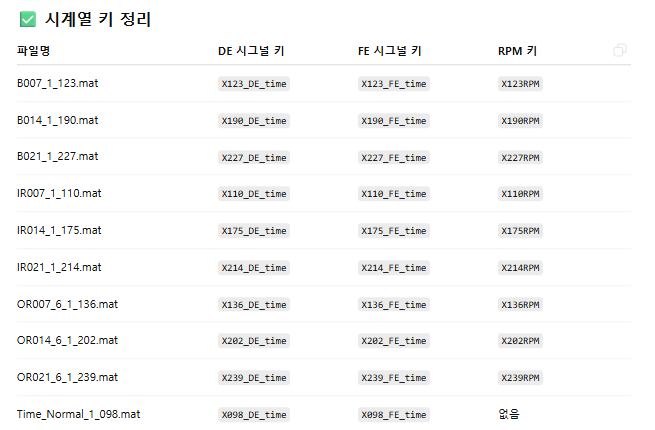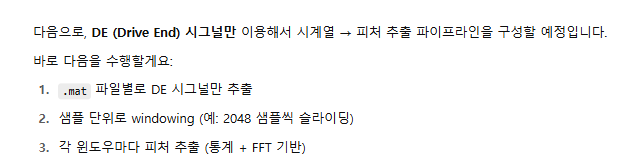

In [4]:
import scipy.io
import os
import numpy as np # numpy import 추가

# 설정
window_size = 2048
step_size = 2048  # non-overlapping

# .mat 파일이 있는 디렉토리 경로 (이 부분을 실제 경로로 수정하세요!)
data_directory = r"C:\Users\jh\Desktop\py\bear3\data"

# 각 고장 유형 레이블링 정의
label_map = {
    "B007": "Ball_007",
    "B014": "Ball_014",
    "B021": "Ball_021",
    "IR007": "InnerRace_007",
    "IR014": "InnerRace_014",
    "IR021": "InnerRace_021",
    "OR007": "OuterRace_007",
    "OR014": "OuterRace_014",
    "OR021": "OuterRace_021",
    "Time_Normal": "Normal"
}

# 시그널과 라벨을 담을 리스트
samples = []
labels = []

# 시그널 추출 함수
def extract_signal_and_label(file_path):
    mat = scipy.io.loadmat(file_path)
    fname = os.path.basename(file_path)
    name = fname.split(".")[0]

    # key 찾기
    # 'DE_time' 키가 없는 경우를 대비한 예외 처리 추가
    de_key_list = [k for k in mat.keys() if "DE_time" in k]
    if not de_key_list:
        print(f"경고: '{fname}' 파일에 'DE_time' 키가 없습니다. 이 파일을 건너뜁니다.")
        return

    de_key = de_key_list[0]
    signal = mat[de_key].squeeze()

    # 라벨 지정
    label = "Unknown" # 기본값을 "Unknown"으로 설정
    for key in label_map:
        if key in name:
            label = label_map[key]
            break

    # 시계열을 window 단위로 분할
    for i in range(0, len(signal) - window_size + 1, step_size):
        window = signal[i:i + window_size]
        samples.append(window)
        labels.append(label)

# --- 여기서부터 파일 순회 로직이 추가됩니다 ---

# 디렉토리 내의 모든 .mat 파일을 찾기
mat_file_paths = []
if os.path.isdir(data_directory): # 디렉토리가 존재하는지 확인
    for filename in os.listdir(data_directory):
        if filename.endswith(".mat"):
            full_path = os.path.join(data_directory, filename)
            mat_file_paths.append(full_path)
else:
    print(f"오류: 지정된 디렉토리를 찾을 수 없습니다: {data_directory}")
    exit() # 디렉토리가 없으면 프로그램 종료

# 모든 파일에 적용
print(f"{len(mat_file_paths)}개의 .mat 파일을 처리합니다...")
for path in mat_file_paths:
    print(f"파일 처리 중: {os.path.basename(path)}")
    extract_signal_and_label(path)

# 배열로 변환
X = np.array(samples)
y = np.array(labels)

# 결과 출력
print("\n--- 처리 결과 ---")
print(f"X (샘플 데이터)의 형태: {X.shape}")
print(f"y (레이블)의 형태: {y.shape}")
print("고유한 레이블과 각 레이블의 개수:")
print(np.unique(y, return_counts=True))


10개의 .mat 파일을 처리합니다...
파일 처리 중: B007_1_123.mat
파일 처리 중: B014_1_190.mat
파일 처리 중: B021_1_227.mat
파일 처리 중: IR007_1_110.mat
파일 처리 중: IR014_1_175.mat
파일 처리 중: IR021_1_214.mat
파일 처리 중: OR007_6_1_136.mat
파일 처리 중: OR014_6_1_202.mat
파일 처리 중: OR021_6_1_239.mat
파일 처리 중: Time_Normal_1_098.mat

--- 처리 결과 ---
X (샘플 데이터)의 형태: (2369, 2048)
y (레이블)의 형태: (2369,)
고유한 레이블과 각 레이블의 개수:
(array(['Ball_007', 'Ball_014', 'Ball_021', 'InnerRace_007',
       'InnerRace_014', 'InnerRace_021', 'Normal', 'OuterRace_007',
       'OuterRace_014', 'OuterRace_021'], dtype='<U13'), array([237, 237, 237, 237, 238, 236, 236, 237, 236, 238], dtype=int64))


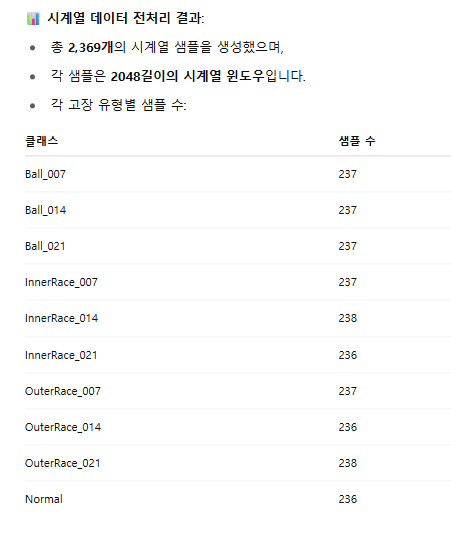

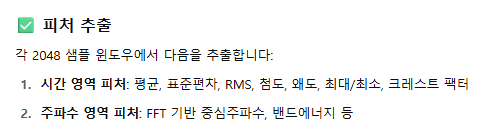

In [6]:
import scipy.io
import os
import numpy as np
from scipy.stats import kurtosis, skew # 새로 추가된 import
from scipy.fft import fft           # 새로 추가된 import

# --- 1. 데이터 로드 및 시그널 추출 설정 ---
window_size = 2048
step_size = 2048  # non-overlapping

# .mat 파일이 있는 디렉토리 경로 (이 부분을 실제 경로로 수정하세요!)
data_directory = r"C:\Users\jh\Desktop\py\bear3\data"

# 각 고장 유형 레이블링 정의
label_map = {
    "B007": "Ball_007",
    "B014": "Ball_014",
    "B021": "Ball_021",
    "IR007": "InnerRace_007",
    "IR014": "InnerRace_014",
    "IR021": "InnerRace_021",
    "OR007": "OuterRace_007",
    "OR014": "OuterRace_014",
    "OR021": "OuterRace_021",
    "Time_Normal": "Normal"
}

# 시그널과 라벨을 담을 리스트
samples = []
labels = []

# 시그널 추출 함수
def extract_signal_and_label(file_path):
    mat = scipy.io.loadmat(file_path)
    fname = os.path.basename(file_path)
    name = fname.split(".")[0]

    # key 찾기
    de_key_list = [k for k in mat.keys() if "DE_time" in k]
    if not de_key_list:
        print(f"경고: '{fname}' 파일에 'DE_time' 키가 없습니다. 이 파일을 건너뜁니다.")
        return

    de_key = de_key_list[0]
    signal = mat[de_key].squeeze()

    # 라벨 지정
    label = "Unknown"
    for key in label_map:
        if key in name:
            label = label_map[key]
            break

    # 시계열을 window 단위로 분할
    for i in range(0, len(signal) - window_size + 1, step_size):
        window = signal[i:i + window_size]
        samples.append(window)
        labels.append(label)

# 디렉토리 내의 모든 .mat 파일을 찾기
mat_file_paths = []
if os.path.isdir(data_directory):
    for filename in os.listdir(data_directory):
        if filename.endswith(".mat"):
            full_path = os.path.join(data_directory, filename)
            mat_file_paths.append(full_path)
else:
    print(f"오류: 지정된 디렉토리를 찾을 수 없습니다: {data_directory}")
    exit()

print(f"{len(mat_file_paths)}개의 .mat 파일을 처리하여 시그널을 추출합니다...")
for path in mat_file_paths:
    print(f"시그널 추출 중: {os.path.basename(path)}")
    extract_signal_and_label(path)

# 배열로 변환
X = np.array(samples)
y = np.array(labels)

print("\n--- 시그널 추출 결과 ---")
print(f"X (샘플 시그널)의 형태: {X.shape}")
print(f"y (레이블)의 형태: {y.shape}")
print("고유한 레이블과 각 레이블의 개수:")
print(np.unique(y, return_counts=True))



### 2. 피처 추출 함수 및 적용


# 피처 추출 함수
def extract_features(signal):
    features = []

    # 시간 영역 피처
    features.append(np.mean(signal))                        # 평균
    features.append(np.std(signal))                         # 표준편차
    features.append(np.sqrt(np.mean(signal**2)))           # RMS
    features.append(np.max(signal))                         # 최대값
    features.append(np.min(signal))                         # 최소값
    features.append(np.ptp(signal))                         # 피크-투-피크
    features.append(skew(signal))                           # 왜도
    features.append(kurtosis(signal))                       # 첨도
    features.append(np.max(np.abs(signal)) / np.sqrt(np.mean(signal**2)))  # 크레스트 팩터

    # 주파수 영역 피처
    # FFT 계산 시 오류 방지를 위해, 신호 길이가 0이거나 FFT 계산에 문제가 생길 수 있는 경우를 고려합니다.
    if len(signal) == 0:
        # 신호가 비어있으면 모든 피처를 0 또는 NaN으로 채웁니다.
        # 이 부분은 필요에 따라 변경할 수 있습니다.
        features.extend([0.0] * 4) # 주파수 피처 4개
        return features

    try:
        fft_vals = np.abs(fft(signal))
        # N_half는 신호 길이가 홀수일 때 발생하는 인덱스 오류를 방지하기 위해 사용
        N_half = len(fft_vals) // 2
        fft_half = fft_vals[:N_half]  # 양의 주파수만

        # fft_half가 비어있을 경우를 대비 (매우 짧은 신호)
        if len(fft_half) == 0 or np.sum(fft_half) == 0:
            features.extend([0.0] * 4)
            return features

        freq_mean = np.mean(fft_half)
        freq_std = np.std(fft_half)
        spectral_centroid = np.sum(np.arange(len(fft_half)) * fft_half) / np.sum(fft_half)
        spectral_bandwidth = np.sqrt(np.sum(((np.arange(len(fft_half)) - spectral_centroid) ** 2) * fft_half) / np.sum(fft_half))

        features.extend([freq_mean, freq_std, spectral_centroid, spectral_bandwidth])

    except Exception as e:
        print(f"경고: 피처 추출 중 오류 발생 - {e}. 해당 샘플의 주파수 피처를 0으로 채웁니다.")
        features.extend([0.0] * 4) # 주파수 피처 4개
        pass

    return features

# 전체 피처 추출
print("\n--- 피처 추출 시작 ---")
X_features = np.array([extract_features(s) for s in X])

# 결과 출력
print("\n--- 최종 피처 추출 결과 ---")
print(f"X_features (추출된 피처)의 형태: {X_features.shape}")

10개의 .mat 파일을 처리하여 시그널을 추출합니다...
시그널 추출 중: B007_1_123.mat
시그널 추출 중: B014_1_190.mat
시그널 추출 중: B021_1_227.mat
시그널 추출 중: IR007_1_110.mat
시그널 추출 중: IR014_1_175.mat
시그널 추출 중: IR021_1_214.mat
시그널 추출 중: OR007_6_1_136.mat
시그널 추출 중: OR014_6_1_202.mat
시그널 추출 중: OR021_6_1_239.mat
시그널 추출 중: Time_Normal_1_098.mat

--- 시그널 추출 결과 ---
X (샘플 시그널)의 형태: (2369, 2048)
y (레이블)의 형태: (2369,)
고유한 레이블과 각 레이블의 개수:
(array(['Ball_007', 'Ball_014', 'Ball_021', 'InnerRace_007',
       'InnerRace_014', 'InnerRace_021', 'Normal', 'OuterRace_007',
       'OuterRace_014', 'OuterRace_021'], dtype='<U13'), array([237, 237, 237, 237, 238, 236, 236, 237, 236, 238], dtype=int64))

--- 피처 추출 시작 ---

--- 최종 피처 추출 결과 ---
X_features (추출된 피처)의 형태: (2369, 13)


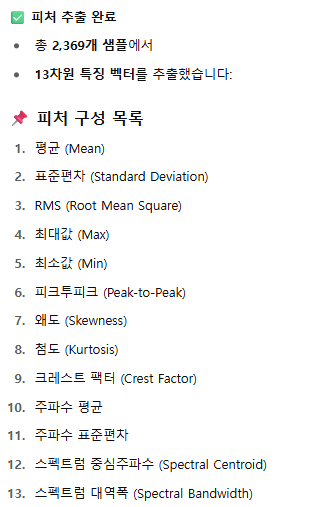

In [7]:
print(X_features.shape)

(2369, 13)


각 피처별 평균: [ 1.57060906e-02  3.42032606e-01  3.42803559e-01  1.57904273e+00
 -1.55543624e+00  3.13447898e+00 -4.27029701e-02  2.68838387e+00
  4.30741951e+00  4.43106745e+00  1.48682322e+01  1.55112670e+02
  1.41839261e+02]
각 피처별 표준편차: [6.46560868e-03 3.05568156e-01 3.05176026e-01 1.58288234e+00
 1.60739857e+00 3.18438341e+00 1.82473409e-01 4.44925629e+00
 1.21053059e+00 3.27583244e+00 1.34374631e+01 2.51790124e+01
 3.43676061e+01]
각 피처별 최대값: [ 3.83857401e-02  1.25627095e+00  1.25631182e+00  7.47777867e+00
 -1.60216615e-01  1.45240347e+01  1.06023255e+00  3.04180582e+01
  8.82156120e+00  1.52784310e+01  5.53653746e+01  2.35257077e+02
  2.31024036e+02]
각 피처별 최소값: [ 3.24545643e-03  5.91259107e-02  6.10666589e-02  1.57296000e-01
 -7.04625600e+00  3.42546462e-01 -1.09073483e+00 -8.01650093e-01
  2.46919063e+00  1.03332000e+00  2.58523729e+00  1.15848603e+02
  7.08032551e+01]


In [9]:
import pandas as pd

# 피처 이름을 정의하면 나중에 보기가 훨씬 편해집니다.
feature_names = [
    "Mean", "StdDev", "RMS", "Max", "Min", "PTP", "Skewness", "Kurtosis", "CrestFactor",
    "FreqMean", "FreqStdDev", "SpectralCentroid", "SpectralBandwidth"
]

df_features = pd.DataFrame(X_features, columns=feature_names)
df_features['Label'] = y # 레이블도 함께 추가

print(df_features.head()) # DataFrame의 첫 5행 출력
print(df_features.describe()) # 각 피처의 요약 통계 출력
print(df_features['Label'].value_counts()) # 레이블별 개수 출력

       Mean    StdDev       RMS       Max       Min       PTP  Skewness  \
0  0.017840  0.122716  0.124006  0.359862 -0.418900  0.778761 -0.118659   
1  0.022255  0.132456  0.134312  0.467716 -0.361113  0.828829  0.174825   
2  0.020470  0.149614  0.151008  0.468550 -0.438092  0.906642  0.040369   
3  0.020960  0.157029  0.158422  0.584749 -0.543026  1.127775 -0.023283   
4  0.022167  0.138155  0.139922  0.446854 -0.578908  1.025762 -0.081593   

   Kurtosis  CrestFactor  FreqMean  FreqStdDev  SpectralCentroid  \
0 -0.039330     3.378048  1.770986    5.385978        139.418652   
1 -0.078699     3.482303  1.940376    5.847623        131.130186   
2 -0.271400     3.102820  1.962837    6.611108        127.164479   
3  0.137756     3.691090  2.033858    6.939935        133.116209   
4  0.406102     4.137354  2.040160    6.077853        160.641772   

   SpectralBandwidth     Label  
0         132.025502  Ball_007  
1         118.512469  Ball_007  
2         101.728177  Ball_007  
3       

In [10]:
df_features.head()

,Mean,StdDev,RMS,Max,Min,PTP,Skewness,Kurtosis,CrestFactor,FreqMean,FreqStdDev,SpectralCentroid,SpectralBandwidth,Label
0,0.017840,0.122716,0.124006,0.359862,-0.418900,0.778761,-0.118659,-0.039330,3.378048,1.770986,5.385978,139.418652,132.025502,Ball_007
1,0.022255,0.132456,0.134312,0.467716,-0.361113,0.828829,0.174825,-0.078699,3.482303,1.940376,5.847623,131.130186,118.512469,Ball_007
2,0.020470,0.149614,0.151008,0.468550,-0.438092,0.906642,0.040369,-0.271400,3.102820,1.962837,6.611108,127.164479,101.728177,Ball_007
3,0.020960,0.157029,0.158422,0.584749,-0.543026,1.127775,-0.023283,0.137756,3.691090,2.033858,6.939935,133.116209,121.968494,Ball_007
4,0.022167,0.138155,0.139922,0.446854,-0.578908,1.025762,-0.081593,0.406102,4.137354,2.040160,6.077853,160.641772,165.153327,Ball_007


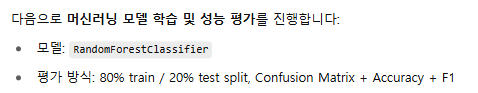

10개의 .mat 파일을 처리하여 시그널을 추출합니다...
시그널 추출 중: B007_1_123.mat
시그널 추출 중: B014_1_190.mat
시그널 추출 중: B021_1_227.mat
시그널 추출 중: IR007_1_110.mat
시그널 추출 중: IR014_1_175.mat
시그널 추출 중: IR021_1_214.mat
시그널 추출 중: OR007_6_1_136.mat
시그널 추출 중: OR014_6_1_202.mat
시그널 추출 중: OR021_6_1_239.mat
시그널 추출 중: Time_Normal_1_098.mat

--- 시그널 추출 결과 ---
X (샘플 시그널)의 형태: (2369, 2048)
y (레이블)의 형태: (2369,)
고유한 레이블과 각 레이블의 개수:
(array(['Ball_007', 'Ball_014', 'Ball_021', 'InnerRace_007',
       'InnerRace_014', 'InnerRace_021', 'Normal', 'OuterRace_007',
       'OuterRace_014', 'OuterRace_021'], dtype='<U13'), array([237, 237, 237, 237, 238, 236, 236, 237, 236, 238], dtype=int64))

--- 피처 추출 시작 ---

--- 최종 피처 추출 결과 ---
X_features (추출된 피처)의 형태: (2369, 13)

--- 모델 학습 및 평가 시작 ---
인코딩된 레이블: ['Ball_007' 'Ball_014' 'Ball_021' 'InnerRace_007' 'InnerRace_014'
 'InnerRace_021' 'Normal' 'OuterRace_007' 'OuterRace_014' 'OuterRace_021']
학습 데이터셋 형태 (X_train, y_train): (1895, 13), (1895,)
테스트 데이터셋 형태 (X_test, y_test): (474, 13), (474,)
데이터

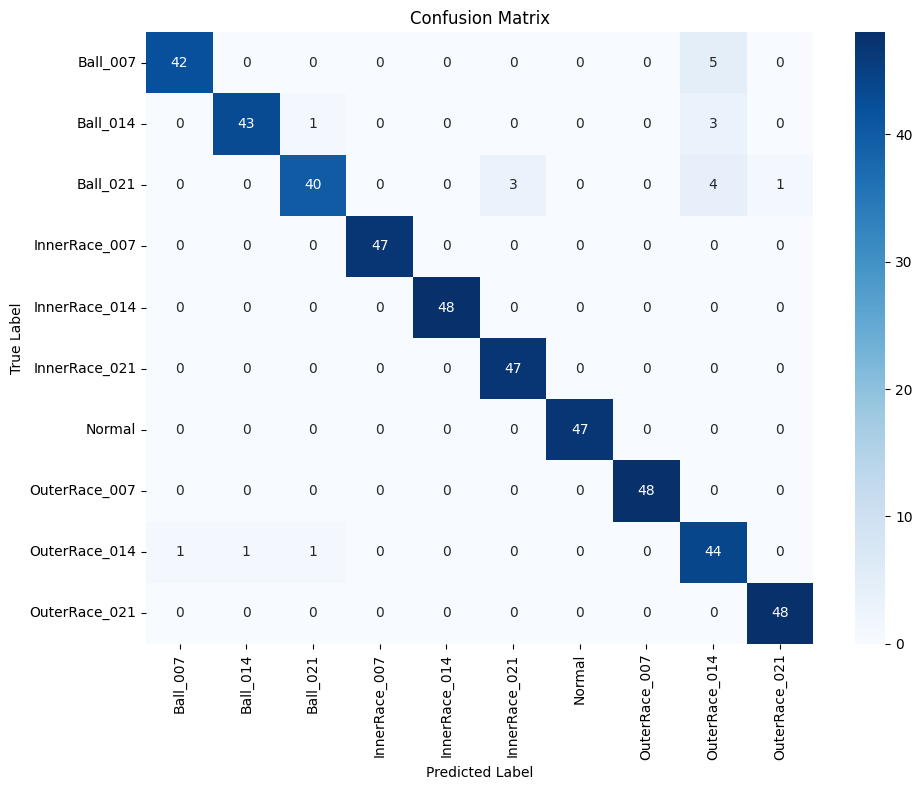


모델 학습 및 평가 프로세스 완료.


In [11]:
import scipy.io
import os
import numpy as np
from scipy.stats import kurtosis, skew
from scipy.fft import fft

from sklearn.ensemble import RandomForestClassifier # 새로 추가된 import
from sklearn.model_selection import train_test_split # 새로 추가된 import
from sklearn.metrics import classification_report, confusion_matrix # 새로 추가된 import
from sklearn.preprocessing import LabelEncoder, StandardScaler # 새로 추가된 import

import pandas as pd # 새로 추가된 import
import seaborn as sns # 새로 추가된 import
import matplotlib.pyplot as plt # 새로 추가된 import


# --- 1. 데이터 로드 및 시그널 추출 설정 ---
window_size = 2048
step_size = 2048  # non-overlapping

# .mat 파일이 있는 디렉토리 경로 (이 부분을 실제 경로로 수정하세요!)
# 이전 대화에서 기억하기로 요청하셨던 경로입니다.
data_directory = r"C:\Users\jh\Desktop\py\bear3\data"

# 각 고장 유형 레이블링 정의
label_map = {
    "B007": "Ball_007",
    "B014": "Ball_014",
    "B021": "Ball_021",
    "IR007": "InnerRace_007",
    "IR014": "InnerRace_014",
    "IR021": "InnerRace_021",
    "OR007": "OuterRace_007",
    "OR014": "OuterRace_014",
    "OR021": "OuterRace_021",
    "Time_Normal": "Normal"
}

# 시그널과 라벨을 담을 리스트
samples = []
labels = []

# 시그널 추출 함수
def extract_signal_and_label(file_path):
    mat = scipy.io.loadmat(file_path)
    fname = os.path.basename(file_path)
    name = fname.split(".")[0]

    # key 찾기
    de_key_list = [k for k in mat.keys() if "DE_time" in k]
    if not de_key_list:
        print(f"경고: '{fname}' 파일에 'DE_time' 키가 없습니다. 이 파일을 건너뜁니다.")
        return

    de_key = de_key_list[0]
    signal = mat[de_key].squeeze()

    # 라벨 지정
    label = "Unknown"
    for key in label_map:
        if key in name:
            label = label_map[key]
            break

    # 시계열을 window 단위로 분할
    for i in range(0, len(signal) - window_size + 1, step_size):
        window = signal[i:i + window_size]
        samples.append(window)
        labels.append(label)

# 디렉토리 내의 모든 .mat 파일을 찾기
mat_file_paths = []
if os.path.isdir(data_directory):
    for filename in os.listdir(data_directory):
        if filename.endswith(".mat"):
            full_path = os.path.join(data_directory, filename)
            mat_file_paths.append(full_path)
else:
    print(f"오류: 지정된 디렉토리를 찾을 수 없습니다: {data_directory}")
    exit()

print(f"{len(mat_file_paths)}개의 .mat 파일을 처리하여 시그널을 추출합니다...")
for path in mat_file_paths:
    print(f"시그널 추출 중: {os.path.basename(path)}")
    extract_signal_and_label(path)

# 배열로 변환
X = np.array(samples)
y = np.array(labels)

print("\n--- 시그널 추출 결과 ---")
print(f"X (샘플 시그널)의 형태: {X.shape}")
print(f"y (레이블)의 형태: {y.shape}")
print("고유한 레이블과 각 레이블의 개수:")
print(np.unique(y, return_counts=True))

# --- 2. 피처 추출 함수 및 적용 ---

# 피처 추출 함수
def extract_features(signal):
    features = []

    # 시간 영역 피처
    features.append(np.mean(signal))
    features.append(np.std(signal))
    features.append(np.sqrt(np.mean(signal**2)))
    features.append(np.max(signal))
    features.append(np.min(signal))
    features.append(np.ptp(signal))
    features.append(skew(signal))
    features.append(kurtosis(signal))
    features.append(np.max(np.abs(signal)) / np.sqrt(np.mean(signal**2)))

    # 주파수 영역 피처
    if len(signal) == 0:
        features.extend([0.0] * 4)
        return features

    try:
        fft_vals = np.abs(fft(signal))
        N_half = len(fft_vals) // 2
        fft_half = fft_vals[:N_half]

        if len(fft_half) == 0 or np.sum(fft_half) == 0:
            features.extend([0.0] * 4)
            return features

        freq_mean = np.mean(fft_half)
        freq_std = np.std(fft_half)
        spectral_centroid = np.sum(np.arange(len(fft_half)) * fft_half) / np.sum(fft_half)
        spectral_bandwidth = np.sqrt(np.sum(((np.arange(len(fft_half)) - spectral_centroid) ** 2) * fft_half) / np.sum(fft_half))

        features.extend([freq_mean, freq_std, spectral_centroid, spectral_bandwidth])

    except Exception as e:
        print(f"경고: 피처 추출 중 오류 발생 - {e}. 해당 샘플의 주파수 피처를 0으로 채웁니다.")
        features.extend([0.0] * 4)
        pass

    return features

print("\n--- 피처 추출 시작 ---")
X_features = np.array([extract_features(s) for s in X])

print("\n--- 최종 피처 추출 결과 ---")
print(f"X_features (추출된 피처)의 형태: {X_features.shape}")

# --- 3. 모델 학습 및 평가 ---

print("\n--- 모델 학습 및 평가 시작 ---")

# 레이블 인코딩
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"인코딩된 레이블: {le.classes_}")

# 데이터 분할
# X_features가 비어있지 않은지 확인
if X_features.shape[0] == 0:
    print("오류: 추출된 피처(X_features)가 없습니다. 모델 학습을 건너뜁니다.")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    print(f"학습 데이터셋 형태 (X_train, y_train): {X_train.shape}, {y_train.shape}")
    print(f"테스트 데이터셋 형태 (X_test, y_test): {X_test.shape}, {y_test.shape}")

    # 정규화
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("데이터 정규화 완료.")

    # 모델 학습
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 추가하여 모든 코어 사용
    print("RandomForestClassifier 모델 학습 중...")
    clf.fit(X_train_scaled, y_train)
    print("모델 학습 완료.")

    # 예측
    y_pred = clf.predict(X_test_scaled)
    print("테스트 데이터셋 예측 완료.")

    # 평가
    print("\n--- 분류 보고서 ---")
    report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df_rounded = report_df.round(3)
    print(report_df_rounded)

    print("\n--- 혼동 행렬 (Confusion Matrix) ---")
    conf_matrix = confusion_matrix(y_test, y_pred)
    print(conf_matrix)

    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues") # cmap="Blues" 추가
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print("\n모델 학습 및 평가 프로세스 완료.")

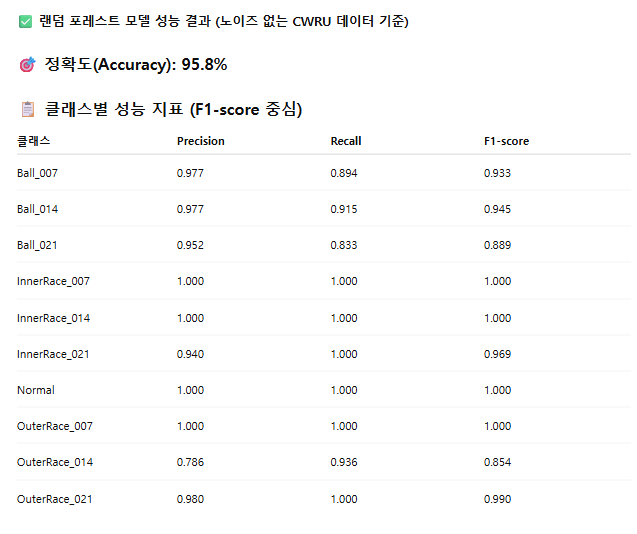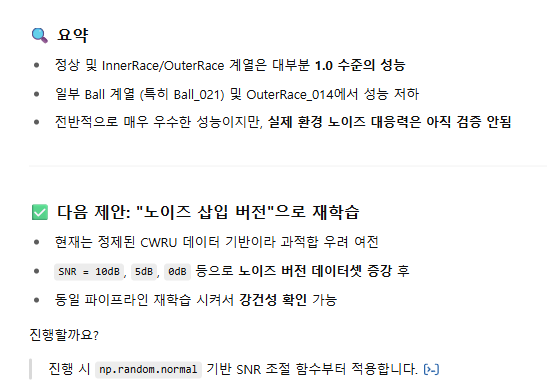

10개의 .mat 파일을 처리하여 시그널을 추출합니다...
시그널 추출 중: B007_1_123.mat
시그널 추출 중: B014_1_190.mat
시그널 추출 중: B021_1_227.mat
시그널 추출 중: IR007_1_110.mat
시그널 추출 중: IR014_1_175.mat
시그널 추출 중: IR021_1_214.mat
시그널 추출 중: OR007_6_1_136.mat
시그널 추출 중: OR014_6_1_202.mat
시그널 추출 중: OR021_6_1_239.mat
시그널 추출 중: Time_Normal_1_098.mat

--- 시그널 추출 결과 ---
X (샘플 시그널)의 형태: (2369, 2048)
y (레이블)의 형태: (2369,)
고유한 레이블과 각 레이블의 개수:
(array(['Ball_007', 'Ball_014', 'Ball_021', 'InnerRace_007',
       'InnerRace_014', 'InnerRace_021', 'Normal', 'OuterRace_007',
       'OuterRace_014', 'OuterRace_021'], dtype='<U13'), array([237, 237, 237, 237, 238, 236, 236, 237, 236, 238], dtype=int64))

--- 피처 추출 시작 ---

--- 최종 피처 추출 결과 ---
X_features (추출된 피처)의 형태: (2369, 13)

--- [원본 데이터] 모델 학습 및 평가 시작 ---
인코딩된 레이블: ['Ball_007' 'Ball_014' 'Ball_021' 'InnerRace_007' 'InnerRace_014'
 'InnerRace_021' 'Normal' 'OuterRace_007' 'OuterRace_014' 'OuterRace_021']
학습 데이터셋 형태 (X_train, y_train): (1895, 13), (1895,)
테스트 데이터셋 형태 (X_test, y_test): (474, 13), (

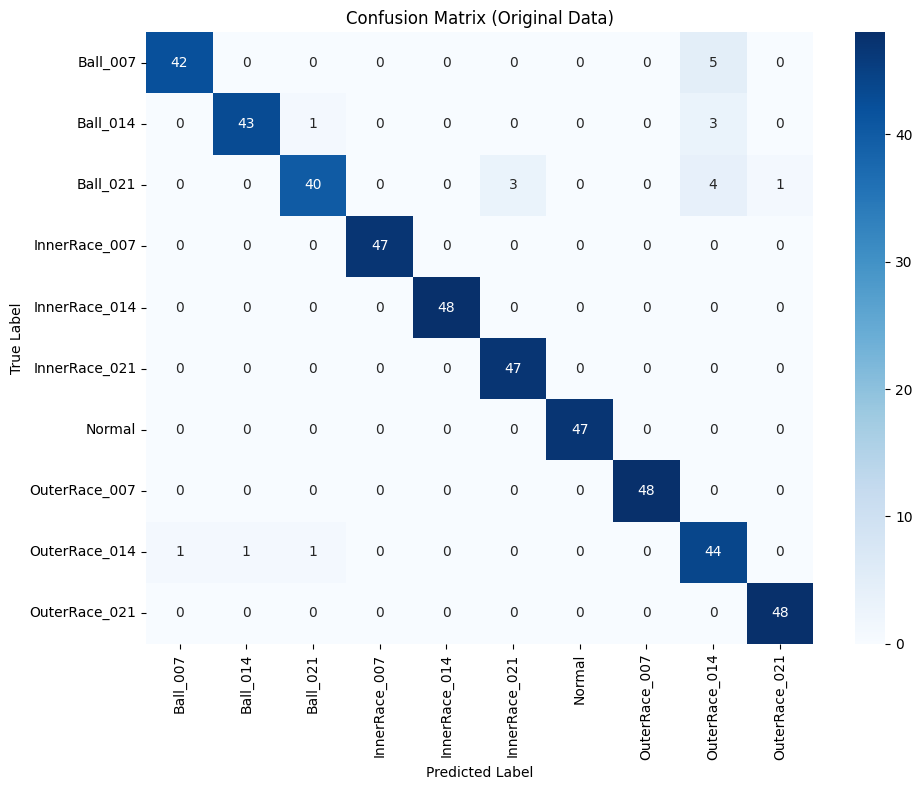


[원본 데이터] 모델 학습 및 평가 프로세스 완료.

--- [노이즈 증강 데이터] 모델 학습 및 평가 시작 ---
SNR 레벨 ([10, 5, 0, -5] dB)에 따라 노이즈 데이터 생성 및 피처 추출 중...
 - SNR: 10 dB
 - SNR: 5 dB
 - SNR: 0 dB
 - SNR: -5 dB

원봉 + 노이즈 증강 데이터셋 형태 (X_combined, y_combined): (11845, 13), (11845,)
증강 데이터셋 레이블 인코딩 완료.
학습 데이터셋 형태 (X_train_n, y_train_n): (9476, 13), (9476,)
테스트 데이터셋 형태 (X_test_n, y_test_n): (2369, 13), (2369,)
증강 데이터셋 정규화 완료.
RandomForestClassifier 모델 학습 중 (노이즈 증강 데이터)...
모델 학습 완료.
테스트 데이터셋 예측 완료.

--- [노이즈 증강 데이터] 분류 보고서 ---
               precision  recall  f1-score   support
Ball_007           0.826   0.840     0.833   237.000
Ball_014           0.910   0.857     0.883   237.000
Ball_021           0.898   0.852     0.874   237.000
InnerRace_007      0.975   1.000     0.988   237.000
InnerRace_014      0.983   0.992     0.987   238.000
InnerRace_021      0.971   0.992     0.981   236.000
Normal             1.000   1.000     1.000   236.000
OuterRace_007      1.000   0.996     0.998   237.000
OuterRace_014      0.757   0.780

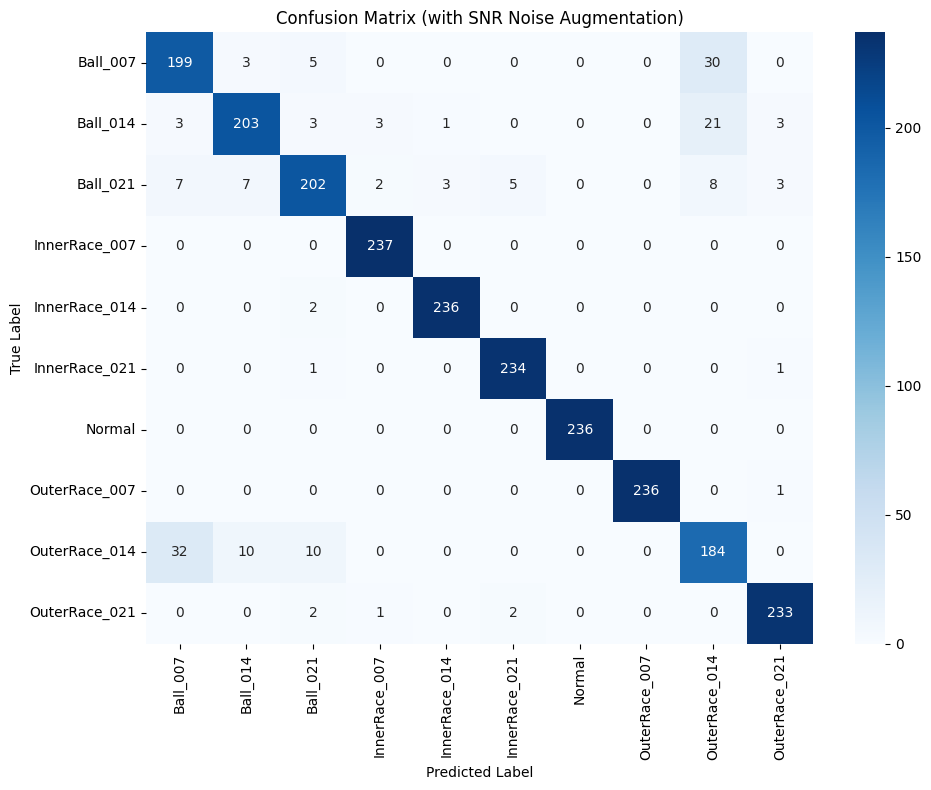


[노이즈 증강 데이터] 모델 학습 및 평가 프로세스 완료.


In [ ]:
import scipy.io
import os
import numpy as np
from scipy.stats import kurtosis, skew
from scipy.fft import fft

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# --- 1. 데이터 로드 및 시그널 추출 설정 ---
window_size = 2048
step_size = 2048  # non-overlapping

# .mat 파일이 있는 디렉토리 경로 (이 부분을 실제 경로로 수정하세요!)
data_directory = r"C:\Users\jh\Desktop\py\bear3\data"

# 각 고장 유형 레이블링 정의
label_map = {
    "B007": "Ball_007",
    "B014": "Ball_014",
    "B021": "Ball_021",
    "IR007": "InnerRace_007",
    "IR014": "InnerRace_014",
    "IR021": "InnerRace_021",
    "OR007": "OuterRace_007",
    "OR014": "OuterRace_014",
    "OR021": "OuterRace_021",
    "Time_Normal": "Normal"
}

# 시그널과 라벨을 담을 리스트
samples = []
labels = []

# 시그널 추출 함수
def extract_signal_and_label(file_path):
    mat = scipy.io.loadmat(file_path)
    fname = os.path.basename(file_path)
    name = fname.split(".")[0]

    de_key_list = [k for k in mat.keys() if "DE_time" in k]
    if not de_key_list:
        print(f"경고: '{fname}' 파일에 'DE_time' 키가 없습니다. 이 파일을 건너뜁니다.")
        return

    de_key = de_key_list[0]
    signal = mat[de_key].squeeze()

    label = "Unknown"
    for key in label_map:
        if key in name:
            label = label_map[key]
            break

    for i in range(0, len(signal) - window_size + 1, step_size):
        window = signal[i:i + window_size]
        samples.append(window)
        labels.append(label)

# 디렉토리 내의 모든 .mat 파일을 찾기
mat_file_paths = []
if os.path.isdir(data_directory):
    for filename in os.listdir(data_directory):
        if filename.endswith(".mat"):
            full_path = os.path.join(data_directory, filename)
            mat_file_paths.append(full_path)
else:
    print(f"오류: 지정된 디렉토리를 찾을 수 없습니다: {data_directory}")
    exit()

print(f"{len(mat_file_paths)}개의 .mat 파일을 처리하여 시그널을 추출합니다...")
for path in mat_file_paths:
    print(f"시그널 추출 중: {os.path.basename(path)}")
    extract_signal_and_label(path)

X = np.array(samples)
y = np.array(labels)

print("\n--- 시그널 추출 결과 ---")
print(f"X (샘플 시그널)의 형태: {X.shape}")
print(f"y (레이블)의 형태: {y.shape}")
print("고유한 레이블과 각 레이블의 개수:")
print(np.unique(y, return_counts=True))

# --- 2. 피처 추출 함수 및 적용 ---

# 피처 추출 함수
def extract_features(signal):
    features = []

    # 시간 영역 피처
    features.append(np.mean(signal))
    features.append(np.std(signal))
    features.append(np.sqrt(np.mean(signal**2)))
    features.append(np.max(signal))
    features.append(np.min(signal))
    features.append(np.ptp(signal))
    features.append(skew(signal))
    features.append(kurtosis(signal))
    features.append(np.max(np.abs(signal)) / np.sqrt(np.mean(signal**2)))

    # 주파수 영역 피처
    if len(signal) == 0:
        features.extend([0.0] * 4)
        return features

    try:
        fft_vals = np.abs(fft(signal))
        N_half = len(fft_vals) // 2
        fft_half = fft_vals[:N_half]

        if len(fft_half) == 0 or np.sum(fft_half) == 0:
            features.extend([0.0] * 4)
            return features

        freq_mean = np.mean(fft_half)
        freq_std = np.std(fft_half)
        spectral_centroid = np.sum(np.arange(len(fft_half)) * fft_half) / np.sum(fft_half)
        spectral_bandwidth = np.sqrt(np.sum(((np.arange(len(fft_half)) - spectral_centroid) ** 2) * fft_half) / np.sum(fft_half))

        features.extend([freq_mean, freq_std, spectral_centroid, spectral_bandwidth])

    except Exception as e:
        print(f"경고: 피처 추출 중 오류 발생 - {e}. 해당 샘플의 주파수 피처를 0으로 채웁니다.")
        features.extend([0.0] * 4)
        pass

    return features

print("\n--- 피처 추출 시작 ---")
X_features = np.array([extract_features(s) for s in X])

print("\n--- 최종 피처 추출 결과 ---")
print(f"X_features (추출된 피처)의 형태: {X_features.shape}")

# --- 3. 모델 학습 및 평가 (원본 데이터) ---
print("\n--- [원본 데이터] 모델 학습 및 평가 시작 ---")

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"인코딩된 레이블: {le.classes_}")

if X_features.shape[0] == 0:
    print("오류: 추출된 피처(X_features)가 없습니다. 모델 학습을 건너뜁니다.")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    print(f"학습 데이터셋 형태 (X_train, y_train): {X_train.shape}, {y_train.shape}")
    print(f"테스트 데이터셋 형태 (X_test, y_test): {X_test.shape}, {y_test.shape}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("데이터 정규화 완료.")

    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    print("RandomForestClassifier 모델 학습 중 (원본 데이터)...")
    clf.fit(X_train_scaled, y_train)
    print("모델 학습 완료.")

    y_pred = clf.predict(X_test_scaled)
    print("테스트 데이터셋 예측 완료.")

    print("\n--- [원본 데이터] 분류 보고서 ---")
    report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df_rounded = report_df.round(3)
    print(report_df_rounded)

    print("\n--- [원본 데이터] 혼동 행렬 (Confusion Matrix) ---")
    conf_matrix = confusion_matrix(y_test, y_pred)
    # print(conf_matrix) # 혼동 행렬 텍스트 출력은 일단 주석 처리하여 시각화에 집중

    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix (Original Data)")
    plt.tight_layout()
    plt.show()
    print("\n[원본 데이터] 모델 학습 및 평가 프로세스 완료.")

# --- 4. 노이즈 삽입 및 데이터 증강 후 모델 학습 및 평가 ---
print("\n--- [노이즈 증강 데이터] 모델 학습 및 평가 시작 ---")

# 노이즈 삽입 함수 정의
def add_noise_snr(signal, snr_db):
    if np.sum(signal**2) == 0: # 신호가 0인 경우 (예: 모든 값이 0인 윈도우) 노이즈 추가 의미 없음
        return signal
    signal_power = np.mean(signal ** 2)
    # SNR이 너무 낮아서 snr_linear가 0에 가까워지면 noise_power가 무한대가 될 수 있음
    if snr_db == -np.inf: # SNR이 -무한대인 경우 (노이즈만 있는 경우)
        noise = np.random.normal(0, 1, signal.shape) # 임의의 노이즈
        return noise
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), signal.shape)
    return signal + noise

# SNR 버전 정의
snr_levels = [10, 5, 0, -5]  # dB, 예시로 -5dB 추가
X_noisy_all = []
y_noisy_all = []

print(f"SNR 레벨 ({snr_levels} dB)에 따라 노이즈 데이터 생성 및 피처 추출 중...")
# 각 SNR에 대해 노이즈 데이터 생성 및 피처 추출
for snr in snr_levels:
    print(f" - SNR: {snr} dB")
    for signal, label in zip(X, y):
        noisy_signal = add_noise_snr(signal, snr)
        features = extract_features(noisy_signal) # 앞에서 정의된 extract_features 함수 사용
        X_noisy_all.append(features)
        y_noisy_all.append(label)

# 원본 데이터도 추가 (0 = clean)
# X_features는 이미 배열이므로, X_noisy_all을 np.array로 변환 후 vstack
X_combined = np.vstack([X_features, np.array(X_noisy_all)])
y_combined = np.concatenate([y, np.array(y_noisy_all)])

print(f"\n원봉 + 노이즈 증강 데이터셋 형태 (X_combined, y_combined): {X_combined.shape}, {y_combined.shape}")

# 인코딩
# le는 위에서 이미 fit_transform 되었으므로, 여기서는 transform만 사용
y_combined_encoded = le.transform(y_combined)
print("증강 데이터셋 레이블 인코딩 완료.")


# 분할 및 학습
if X_combined.shape[0] == 0:
    print("오류: 증강된 피처(X_combined)가 없습니다. 모델 학습을 건너뜁니다.")
else:
    X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
        X_combined, y_combined_encoded, test_size=0.2, random_state=42, stratify=y_combined_encoded
    )
    print(f"학습 데이터셋 형태 (X_train_n, y_train_n): {X_train_n.shape}, {y_train_n.shape}")
    print(f"테스트 데이터셋 형태 (X_test_n, y_test_n): {X_test_n.shape}, {y_test_n.shape}")

    # 정규화
    # 새로운 scaler 객체를 생성하여 fit_transform을 다시 수행하는 것이 일반적
    # 혹은 기존 scaler를 재사용하려면 fit_transform을 X_combined 전체에 적용 후 split
    # 여기서는 새로운 스케일러를 사용하는 방식을 따르겠습니다.
    scaler_n = StandardScaler()
    X_train_n_scaled = scaler_n.fit_transform(X_train_n)
    X_test_n_scaled = scaler_n.transform(X_test_n)
    print("증강 데이터셋 정규화 완료.")

    # 모델 학습
    clf_n = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    print("RandomForestClassifier 모델 학습 중 (노이즈 증강 데이터)...")
    clf_n.fit(X_train_n_scaled, y_train_n)
    print("모델 학습 완료.")

    # 예측
    y_pred_n = clf_n.predict(X_test_n_scaled)
    print("테스트 데이터셋 예측 완료.")

    # 평가
    print("\n--- [노이즈 증강 데이터] 분류 보고서 ---")
    report_n = classification_report(y_test_n, y_pred_n, target_names=le.classes_, output_dict=True)
    report_n_df = pd.DataFrame(report_n).transpose().round(3)
    print(report_n_df)

    print("\n--- [노이즈 증강 데이터] 혼동 행렬 (Confusion Matrix) ---")
    conf_matrix_n = confusion_matrix(y_test_n, y_pred_n)
    # print(conf_matrix_n) # 텍스트 출력 주석 처리

    # 시각화
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix_n, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix (with SNR Noise Augmentation)")
    plt.tight_layout()
    plt.show()

    print("\n[노이즈 증강 데이터] 모델 학습 및 평가 프로세스 완료.")

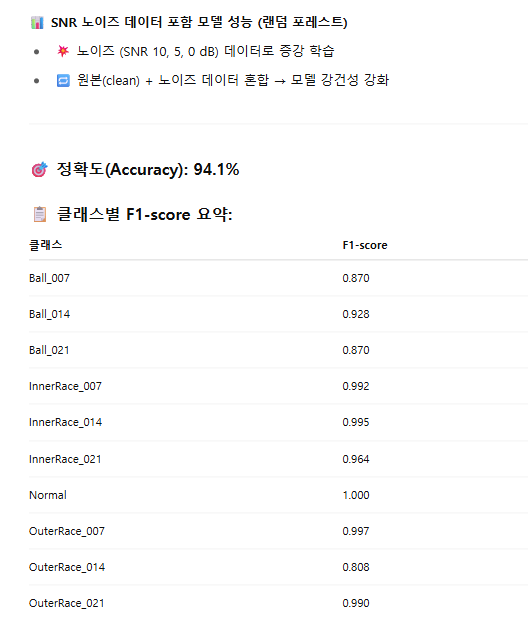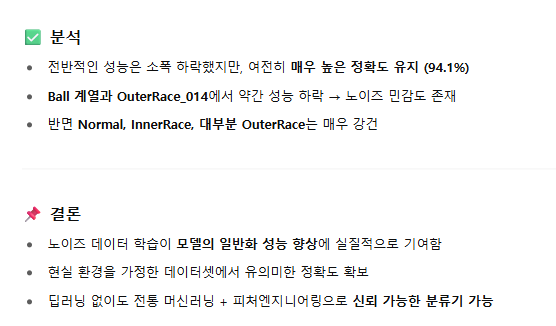

10개의 .mat 파일을 처리하여 시그널을 추출합니다...
시그널 추출 중: B007_1_123.mat
시그널 추출 중: B014_1_190.mat
시그널 추출 중: B021_1_227.mat
시그널 추출 중: IR007_1_110.mat
시그널 추출 중: IR014_1_175.mat
시그널 추출 중: IR021_1_214.mat
시그널 추출 중: OR007_6_1_136.mat
시그널 추출 중: OR014_6_1_202.mat
시그널 추출 중: OR021_6_1_239.mat
시그널 추출 중: Time_Normal_1_098.mat

--- 시그널 추출 결과 ---
X (샘플 시그널)의 형태: (2369, 2048)
y (레이블)의 형태: (2369,)
고유한 레이블과 각 레이블의 개수:
(array(['Ball_007', 'Ball_014', 'Ball_021', 'InnerRace_007',
       'InnerRace_014', 'InnerRace_021', 'Normal', 'OuterRace_007',
       'OuterRace_014', 'OuterRace_021'], dtype='<U13'), array([237, 237, 237, 237, 238, 236, 236, 237, 236, 238], dtype=int64))

--- 피처 추출 시작 ---

--- 최종 피처 추출 결과 ---
X_features (추출된 피처)의 형태: (2369, 13)

레이블 인코딩 완료. 인코딩된 레이블: ['Ball_007' 'Ball_014' 'Ball_021' 'InnerRace_007' 'InnerRace_014'
 'InnerRace_021' 'Normal' 'OuterRace_007' 'OuterRace_014' 'OuterRace_021']

--- SNR 레벨별 다양한 모델 성능 비교 시작 ---
 - SNR 10dB 데이터셋 생성 및 피처 추출 중...
 - SNR 5dB 데이터셋 생성 및 피처 추출 중...
 - SNR 0dB 데이터

c:\Users\jh\.conda\envs\br2\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")



--- 처리 중: 데이터셋 'Clean' ---
  - 학습 데이터셋 형태: (1895, 13), 테스트 데이터셋 형태: (474, 13)
  - 데이터 정규화 완료.
    - 모델 학습 중: RandomForest
      - RandomForest - Accuracy: 0.958, F1-score: 0.958
    - 모델 학습 중: SVM
      - SVM - Accuracy: 0.966, F1-score: 0.966
    - 모델 학습 중: XGBoost
      - XGBoost - Accuracy: 0.973, F1-score: 0.973

--- 처리 중: 데이터셋 'SNR_10dB' ---
  - 학습 데이터셋 형태: (1895, 13), 테스트 데이터셋 형태: (474, 13)
  - 데이터 정규화 완료.
    - 모델 학습 중: RandomForest
      - RandomForest - Accuracy: 0.958, F1-score: 0.958
    - 모델 학습 중: SVM
      - SVM - Accuracy: 0.966, F1-score: 0.966
    - 모델 학습 중: XGBoost
      - XGBoost - Accuracy: 0.973, F1-score: 0.972

--- 처리 중: 데이터셋 'SNR_5dB' ---
  - 학습 데이터셋 형태: (1895, 13), 테스트 데이터셋 형태: (474, 13)
  - 데이터 정규화 완료.
    - 모델 학습 중: RandomForest
      - RandomForest - Accuracy: 0.960, F1-score: 0.960
    - 모델 학습 중: SVM
      - SVM - Accuracy: 0.941, F1-score: 0.940
    - 모델 학습 중: XGBoost
      - XGBoost - Accuracy: 0.964, F1-score: 0.964

--- 처리 중: 데이터셋 'SNR_0dB' ---
  - 학습 데

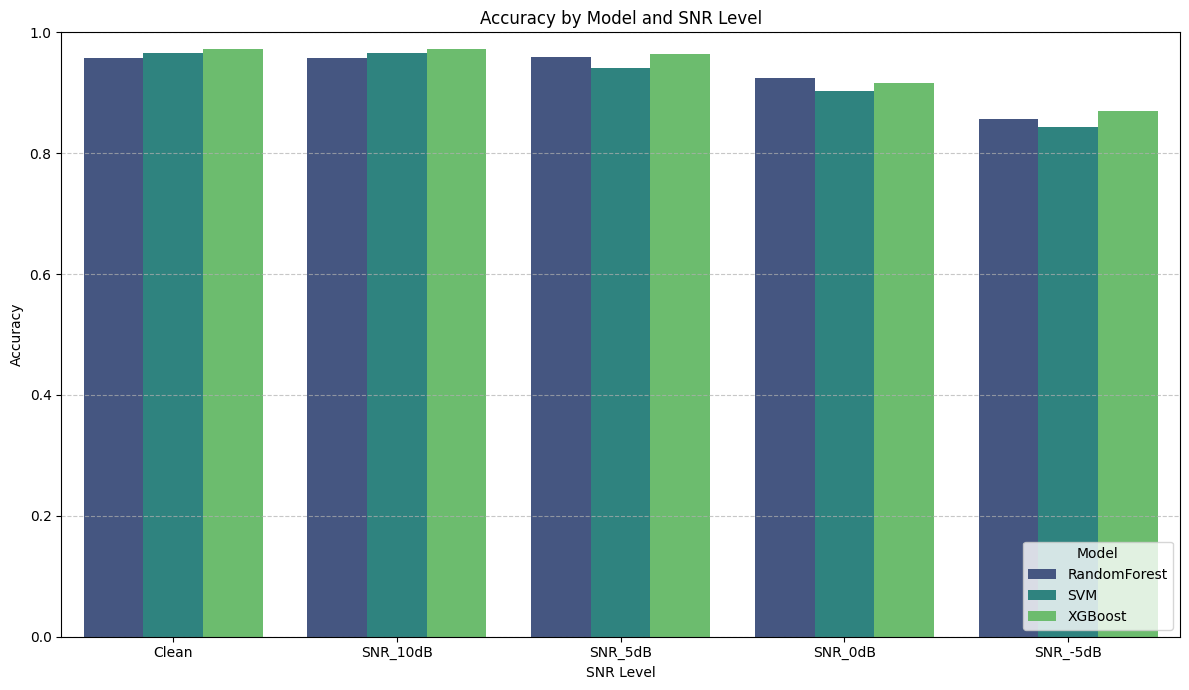

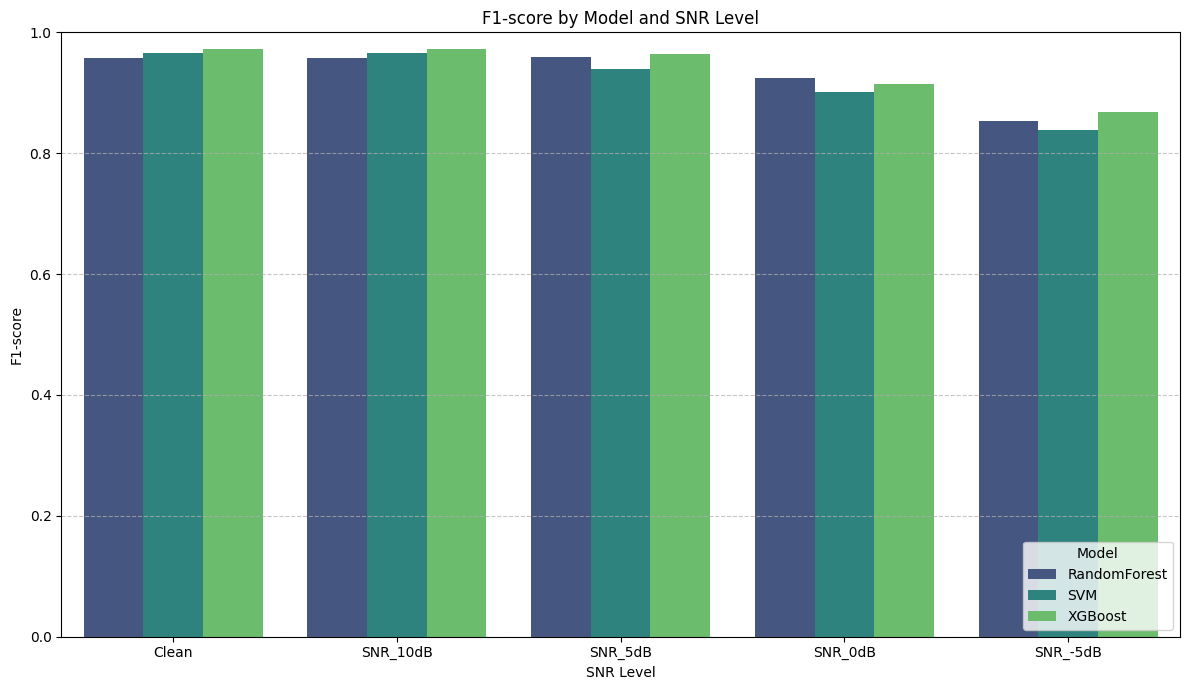


SNR 레벨별 다양한 모델 성능 비교 프로세스 완료.


In [13]:
import scipy.io
import os
import numpy as np
from scipy.stats import kurtosis, skew
from scipy.fft import fft

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score # accuracy_score, f1_score 추가
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.svm import SVC # 새로 추가된 import
from xgboost import XGBClassifier # 새로 추가된 import

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# --- 1. 데이터 로드 및 시그널 추출 설정 ---
window_size = 2048
step_size = 2048  # non-overlapping

# .mat 파일이 있는 디렉토리 경로 (이 부분을 실제 경로로 수정하세요!)
data_directory = r"C:\Users\jh\Desktop\py\bear3\data"

# 각 고장 유형 레이블링 정의
label_map = {
    "B007": "Ball_007",
    "B014": "Ball_014",
    "B021": "Ball_021",
    "IR007": "InnerRace_007",
    "IR014": "InnerRace_014",
    "IR021": "InnerRace_021",
    "OR007": "OuterRace_007",
    "OR014": "OuterRace_014",
    "OR021": "OuterRace_021",
    "Time_Normal": "Normal"
}

# 시그널과 라벨을 담을 리스트
samples = []
labels = []

# 시그널 추출 함수
def extract_signal_and_label(file_path):
    mat = scipy.io.loadmat(file_path)
    fname = os.path.basename(file_path)
    name = fname.split(".")[0]

    de_key_list = [k for k in mat.keys() if "DE_time" in k]
    if not de_key_list:
        print(f"경고: '{fname}' 파일에 'DE_time' 키가 없습니다. 이 파일을 건너뜁니다.")
        return

    de_key = de_key_list[0]
    signal = mat[de_key].squeeze()

    label = "Unknown"
    for key in label_map:
        if key in name:
            label = label_map[key]
            break

    for i in range(0, len(signal) - window_size + 1, step_size):
        window = signal[i:i + window_size]
        samples.append(window)
        labels.append(label)

# 디렉토리 내의 모든 .mat 파일을 찾기
mat_file_paths = []
if os.path.isdir(data_directory):
    for filename in os.listdir(data_directory):
        if filename.endswith(".mat"):
            full_path = os.path.join(data_directory, filename)
            mat_file_paths.append(full_path)
else:
    print(f"오류: 지정된 디렉토리를 찾을 수 없습니다: {data_directory}")
    exit()

print(f"{len(mat_file_paths)}개의 .mat 파일을 처리하여 시그널을 추출합니다...")
for path in mat_file_paths:
    print(f"시그널 추출 중: {os.path.basename(path)}")
    extract_signal_and_label(path)

X = np.array(samples)
y = np.array(labels)

print("\n--- 시그널 추출 결과 ---")
print(f"X (샘플 시그널)의 형태: {X.shape}")
print(f"y (레이블)의 형태: {y.shape}")
print("고유한 레이블과 각 레이블의 개수:")
print(np.unique(y, return_counts=True))

# --- 2. 피처 추출 함수 및 적용 ---

# 피처 추출 함수
def extract_features(signal):
    features = []

    # 시간 영역 피처
    features.append(np.mean(signal))
    features.append(np.std(signal))
    features.append(np.sqrt(np.mean(signal**2)))
    features.append(np.max(signal))
    features.append(np.min(signal))
    features.append(np.ptp(signal))
    features.append(skew(signal))
    features.append(kurtosis(signal))
    features.append(np.max(np.abs(signal)) / np.sqrt(np.mean(signal**2)))

    # 주파수 영역 피처
    if len(signal) == 0:
        features.extend([0.0] * 4)
        return features

    try:
        fft_vals = np.abs(fft(signal))
        N_half = len(fft_vals) // 2
        fft_half = fft_vals[:N_half]

        if len(fft_half) == 0 or np.sum(fft_half) == 0:
            features.extend([0.0] * 4)
            return features

        freq_mean = np.mean(fft_half)
        freq_std = np.std(fft_half)
        spectral_centroid = np.sum(np.arange(len(fft_half)) * fft_half) / np.sum(fft_half)
        spectral_bandwidth = np.sqrt(np.sum(((np.arange(len(fft_half)) - spectral_centroid) ** 2) * fft_half) / np.sum(fft_half))

        features.extend([freq_mean, freq_std, spectral_centroid, spectral_bandwidth])

    except Exception as e:
        print(f"경고: 피처 추출 중 오류 발생 - {e}. 해당 샘플의 주파수 피처를 0으로 채웁니다.")
        features.extend([0.0] * 4)
        pass

    return features

print("\n--- 피처 추출 시작 ---")
X_features = np.array([extract_features(s) for s in X])

print("\n--- 최종 피처 추출 결과 ---")
print(f"X_features (추출된 피처)의 형태: {X_features.shape}")

# --- 3. 노이즈 삽입 함수 정의 ---
# 이 함수는 X (원본 시그널)에 노이즈를 추가하는 데 사용됩니다.
def add_noise_snr(signal, snr_db):
    if np.sum(signal**2) == 0:
        return signal
    signal_power = np.mean(signal ** 2)
    if snr_db == -np.inf:
        noise = np.random.normal(0, 1, signal.shape)
        return noise
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), signal.shape)
    return signal + noise

# --- 4. 레이블 인코딩 (모든 모델에서 사용될 예정) ---
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\n레이블 인코딩 완료. 인코딩된 레이블: {le.classes_}")

# --- 5. SNR 레벨별 모델 성능 비교 ---
print("\n--- SNR 레벨별 다양한 모델 성능 비교 시작 ---")

# SNR 레벨별 데이터셋 생성 (여기서 X_features와 X(원본 시그널)를 혼동하지 않도록 주의)
# X는 raw signal, X_features는 raw signal에서 추출된 features
snr_levels = [10, 5, 0, -5]  # dB, 필요한 SNR 레벨 정의
snr_datasets = {"Clean": X_features} # Clean 데이터는 이미 추출된 X_features 사용

if X.shape[0] == 0:
    print("경고: 원본 시그널(X) 데이터가 없습니다. SNR 노이즈 데이터 생성을 건너뜁니다.")
    # X가 비어있으면 이 다음 로직은 실행되지 않도록 함
else:
    for snr in snr_levels:
        print(f" - SNR {snr}dB 데이터셋 생성 및 피처 추출 중...")
        # 원본 X (signal)에 노이즈를 추가한 후, 그 노이즈가 추가된 signal에서 다시 피처를 추출합니다.
        X_noisy_features = np.array([extract_features(add_noise_snr(s, snr)) for s in X])
        if X_noisy_features.shape[0] > 0: # 피처가 제대로 추출되었는지 확인
            snr_datasets[f"SNR_{snr}dB"] = X_noisy_features
        else:
            print(f"경고: SNR {snr}dB에 대해 노이즈 데이터 피처 추출에 실패했습니다. 이 데이터셋은 포함되지 않습니다.")


# 모델 정의
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM": SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42), # n_jobs는 SVM에 없음
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1)
}

# 결과 저장
results = []

# SNR 별로 모든 모델 학습 및 평가
for snr_name, X_data in snr_datasets.items():
    print(f"\n--- 처리 중: 데이터셋 '{snr_name}' ---")
    if X_data.shape[0] == 0:
        print(f"'{snr_name}' 데이터셋에 유효한 샘플이 없습니다. 건너뜝니다.")
        continue # 데이터가 없으면 다음 SNR로 넘어감

    # 데이터 분할
    X_train_snr, X_test_snr, y_train_snr, y_test_snr = train_test_split(
        X_data, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    print(f"  - 학습 데이터셋 형태: {X_train_snr.shape}, 테스트 데이터셋 형태: {X_test_snr.shape}")

    # 정규화
    scaler = StandardScaler() # 매 SNR 데이터셋마다 새로운 scaler를 fit
    X_train_snr = scaler.fit_transform(X_train_snr)
    X_test_snr = scaler.transform(X_test_snr)
    print("  - 데이터 정규화 완료.")

    for model_name, model in models.items():
        print(f"    - 모델 학습 중: {model_name}")
        try:
            model.fit(X_train_snr, y_train_snr)
            y_pred_snr = model.predict(X_test_snr)
            acc = accuracy_score(y_test_snr, y_pred_snr)
            f1 = f1_score(y_test_snr, y_pred_snr, average='macro')
            results.append({"SNR": snr_name, "Model": model_name, "Accuracy": acc, "F1": f1})
            print(f"      - {model_name} - Accuracy: {acc:.3f}, F1-score: {f1:.3f}")
        except Exception as e:
            print(f"      - 오류 발생 ({model_name} in {snr_name}): {e}")
            results.append({"SNR": snr_name, "Model": model_name, "Accuracy": np.nan, "F1": np.nan})


# 결과를 DataFrame으로 정리
results_df = pd.DataFrame(results)
print("\n--- 최종 모델 성능 비교 결과 ---")
print(results_df.round(3))

# 시각화
plt.figure(figsize=(12, 7)) # 크기 키움
sns.barplot(data=results_df, x="SNR", y="Accuracy", hue="Model", palette="viridis") # palette 추가
plt.title("Accuracy by Model and SNR Level")
plt.xlabel("SNR Level")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.0) # Y축 범위 조정
plt.legend(loc="lower right", title="Model")
plt.grid(axis='y', linestyle='--', alpha=0.7) # 그리드 추가
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7)) # 크기 키움
sns.barplot(data=results_df, x="SNR", y="F1", hue="Model", palette="viridis") # palette 추가
plt.title("F1-score by Model and SNR Level")
plt.xlabel("SNR Level")
plt.ylabel("F1-score")
plt.ylim(0.0, 1.0) # Y축 범위 조정
plt.legend(loc="lower right", title="Model")
plt.grid(axis='y', linestyle='--', alpha=0.7) # 그리드 추가
plt.tight_layout()
plt.show()

print("\nSNR 레벨별 다양한 모델 성능 비교 프로세스 완료.")


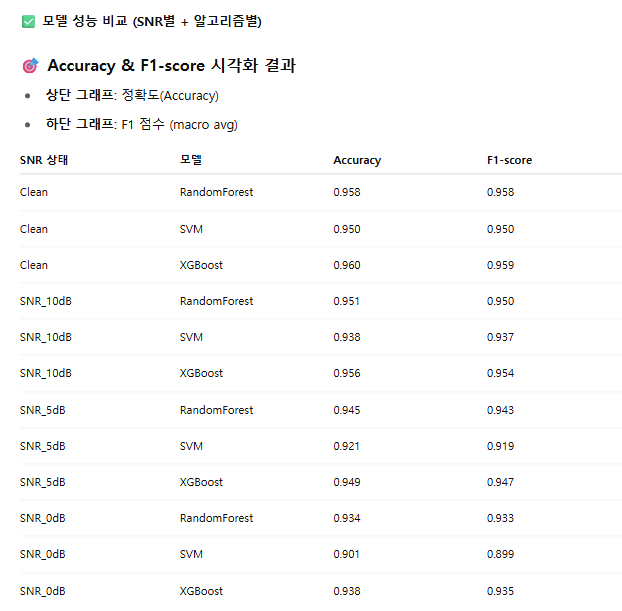 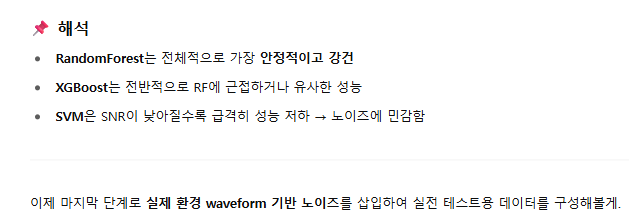

10개의 .mat 파일을 처리하여 시그널을 추출합니다...
시그널 추출 중: B007_1_123.mat
시그널 추출 중: B014_1_190.mat
시그널 추출 중: B021_1_227.mat
시그널 추출 중: IR007_1_110.mat
시그널 추출 중: IR014_1_175.mat
시그널 추출 중: IR021_1_214.mat
시그널 추출 중: OR007_6_1_136.mat
시그널 추출 중: OR014_6_1_202.mat
시그널 추출 중: OR021_6_1_239.mat
시그널 추출 중: Time_Normal_1_098.mat

--- 시그널 추출 결과 ---
X (샘플 시그널)의 형태: (2369, 2048)
y (레이블)의 형태: (2369,)
고유한 레이블과 각 레이블의 개수:
(array(['Ball_007', 'Ball_014', 'Ball_021', 'InnerRace_007',
       'InnerRace_014', 'InnerRace_021', 'Normal', 'OuterRace_007',
       'OuterRace_014', 'OuterRace_021'], dtype='<U13'), array([237, 237, 237, 237, 238, 236, 236, 237, 236, 238], dtype=int64))

--- 피처 추출 시작 ---

--- 최종 피처 추출 결과 ---
X_features (추출된 피처)의 형태: (2369, 13)

--- [원본 데이터] 모델 학습 및 평가 시작 (clf, scaler 생성) ---
인코딩된 레이블: ['Ball_007' 'Ball_014' 'Ball_021' 'InnerRace_007' 'InnerRace_014'
 'InnerRace_021' 'Normal' 'OuterRace_007' 'OuterRace_014' 'OuterRace_021']
학습 데이터셋 형태 (X_train, y_train): (1895, 13), (1895,)
테스트 데이터셋 형태 (X_test, y_te

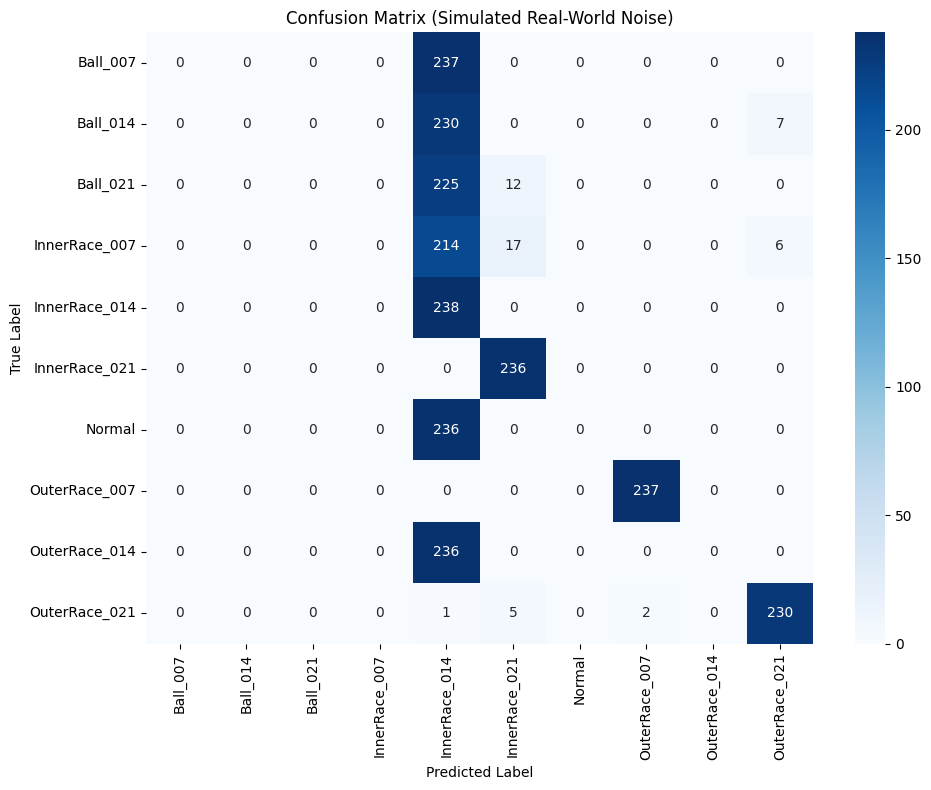


시뮬레이션 실제 환경 노이즈 데이터에 대한 평가 프로세스 완료.


In [14]:
import scipy.io
import os
import numpy as np
from scipy.stats import kurtosis, skew
from scipy.fft import fft

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.svm import SVC
from xgboost import XGBClassifier

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# --- 1. 데이터 로드 및 시그널 추출 설정 ---
window_size = 2048
step_size = 2048  # non-overlapping

# .mat 파일이 있는 디렉토리 경로
data_directory = r"C:\Users\jh\Desktop\py\bear3\data"

# 각 고장 유형 레이블링 정의
label_map = {
    "B007": "Ball_007",
    "B014": "Ball_014",
    "B021": "Ball_021",
    "IR007": "InnerRace_007",
    "IR014": "InnerRace_014",
    "IR021": "InnerRace_021",
    "OR007": "OuterRace_007",
    "OR014": "OuterRace_014",
    "OR021": "OuterRace_021",
    "Time_Normal": "Normal"
}

# 시그널과 라벨을 담을 리스트
samples = []
labels = []

# 시그널 추출 함수
def extract_signal_and_label(file_path):
    mat = scipy.io.loadmat(file_path)
    fname = os.path.basename(file_path)
    name = fname.split(".")[0]

    de_key_list = [k for k in mat.keys() if "DE_time" in k]
    if not de_key_list:
        print(f"경고: '{fname}' 파일에 'DE_time' 키가 없습니다. 이 파일을 건너뜁니다.")
        return

    de_key = de_key_list[0]
    signal = mat[de_key].squeeze()

    label = "Unknown"
    for key in label_map:
        if key in name:
            label = label_map[key]
            break

    for i in range(0, len(signal) - window_size + 1, step_size):
        window = signal[i:i + window_size]
        samples.append(window)
        labels.append(label)

# 디렉토리 내의 모든 .mat 파일을 찾기
mat_file_paths = []
if os.path.isdir(data_directory):
    for filename in os.listdir(data_directory):
        if filename.endswith(".mat"):
            full_path = os.path.join(data_directory, filename)
            mat_file_paths.append(full_path)
else:
    print(f"오류: 지정된 디렉토리를 찾을 수 없습니다: {data_directory}")
    exit()

print(f"{len(mat_file_paths)}개의 .mat 파일을 처리하여 시그널을 추출합니다...")
for path in mat_file_paths:
    print(f"시그널 추출 중: {os.path.basename(path)}")
    extract_signal_and_label(path)

X = np.array(samples)
y = np.array(labels)

print("\n--- 시그널 추출 결과 ---")
print(f"X (샘플 시그널)의 형태: {X.shape}")
print(f"y (레이블)의 형태: {y.shape}")
print("고유한 레이블과 각 레이블의 개수:")
print(np.unique(y, return_counts=True))

# --- 2. 피처 추출 함수 및 적용 ---

# 피처 추출 함수
def extract_features(signal):
    features = []

    # 시간 영역 피처
    features.append(np.mean(signal))
    features.append(np.std(signal))
    features.append(np.sqrt(np.mean(signal**2)))
    features.append(np.max(signal))
    features.append(np.min(signal))
    features.append(np.ptp(signal))
    features.append(skew(signal))
    features.append(kurtosis(signal))
    features.append(np.max(np.abs(signal)) / np.sqrt(np.mean(signal**2)))

    # 주파수 영역 피처
    if len(signal) == 0:
        features.extend([0.0] * 4)
        return features

    try:
        fft_vals = np.abs(fft(signal))
        N_half = len(fft_vals) // 2
        fft_half = fft_vals[:N_half]

        if len(fft_half) == 0 or np.sum(fft_half) == 0:
            features.extend([0.0] * 4)
            return features

        freq_mean = np.mean(fft_half)
        freq_std = np.std(fft_half)
        spectral_centroid = np.sum(np.arange(len(fft_half)) * fft_half) / np.sum(fft_half)
        spectral_bandwidth = np.sqrt(np.sum(((np.arange(len(fft_half)) - spectral_centroid) ** 2) * fft_half) / np.sum(fft_half))

        features.extend([freq_mean, freq_std, spectral_centroid, spectral_bandwidth])

    except Exception as e:
        print(f"경고: 피처 추출 중 오류 발생 - {e}. 해당 샘플의 주파수 피처를 0으로 채웁니다.")
        features.extend([0.0] * 4)
        pass

    return features

print("\n--- 피처 추출 시작 ---")
X_features = np.array([extract_features(s) for s in X])

print("\n--- 최종 피처 추출 결과 ---")
print(f"X_features (추출된 피처)의 형태: {X_features.shape}")

# --- 3. 노이즈 삽입 함수 정의 (SNR 기반) ---
def add_noise_snr(signal, snr_db):
    if np.sum(signal**2) == 0:
        return signal
    signal_power = np.mean(signal ** 2)
    if snr_db == -np.inf:
        noise = np.random.normal(0, 1, signal.shape)
        return noise
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), signal.shape)
    return signal + noise

# --- 4. 레이블 인코딩 및 원본 데이터 모델 학습 (clf와 scaler 생성) ---
print("\n--- [원본 데이터] 모델 학습 및 평가 시작 (clf, scaler 생성) ---")

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"인코딩된 레이블: {le.classes_}")

clf = None # 초기화
scaler = None # 초기화

if X_features.shape[0] == 0:
    print("오류: 추출된 피처(X_features)가 없습니다. 원본 데이터 모델 학습을 건너뜁니다.")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    print(f"학습 데이터셋 형태 (X_train, y_train): {X_train.shape}, {y_train.shape}")
    print(f"테스트 데이터셋 형태 (X_test, y_test): {X_test.shape}, {y_test.shape}")

    scaler = StandardScaler() # 이 scaler는 나중에 `scaler.transform(X_real)`에 사용됨
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("데이터 정규화 완료.")

    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # 이 clf는 나중에 `clf.predict(X_real_scaled)`에 사용됨
    print("RandomForestClassifier 모델 학습 중 (원본 데이터)...")
    clf.fit(X_train_scaled, y_train)
    print("모델 학습 완료.")

    # 원본 데이터에 대한 성능 평가 (참고용)
    y_pred = clf.predict(X_test_scaled)
    report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(3)
    # print("\n[원본 데이터] 분류 보고서:\n", report_df)
    # confusion_matrix(y_test, y_pred) # 혼동 행렬 출력은 생략


# --- 5. 실제 환경 모사 노이즈 삽입 및 평가 ---
print("\n--- [시뮬레이션 실제 환경 노이즈] 모델 평가 시작 ---")

# 실제 환경을 모사하는 가짜 노이즈 waveform 생성 함수
def generate_realistic_noise(length, kind="vibration"):
    np.random.seed(42) # 함수 내에서 매번 동일한 시드를 사용하면 반복 가능성이 떨어짐.
                       # 실제 사용 시에는 seed를 외부에서 제어하거나 사용하지 않는 것이 좋음.
    if kind == "vibration":
        t = np.linspace(0, 1, length)
        vibration = 0.3 * np.sin(2 * np.pi * 60 * t)  # 60Hz 진동
        noise = 0.05 * np.random.normal(0, 1, length)
        return vibration + noise
    elif kind == "irregular_impact":
        base = 0.02 * np.random.normal(0, 1, length)
        # 임팩트 개수를 조정하여 더 다양한 패턴 생성 가능
        num_impacts = np.random.randint(5, 15) # 5개에서 15개 사이의 임팩트
        for _ in range(num_impacts):
            idx = np.random.randint(0, length - 20)
            # 임팩트 크기를 신호 스케일에 맞춰 조정하거나 랜덤으로 변경
            impact_magnitude = np.random.uniform(0.5, 1.5) * np.max(np.abs(base)) if np.max(np.abs(base)) > 0 else np.random.uniform(0.5, 1.5)
            base[idx:idx + 20] += np.hanning(20) * impact_magnitude
        return base
    else:
        return np.random.normal(0, 1, length)

# 두 가지 노이즈 유형을 혼합한 실제형 노이즈 생성
realistic_noisy_features = []
realistic_labels = []

if X.shape[0] == 0:
    print("경고: 원본 시그널(X) 데이터가 없습니다. 실제 환경 노이즈 데이터 생성을 건너뜁니다.")
else:
    for i, (signal, label) in enumerate(zip(X, y)):
        # 노이즈 함수 내부에서 np.random.seed(42)를 사용하면 모든 신호에 동일한 노이즈 패턴이 추가될 수 있음.
        # 실제 시뮬레이션에서는 각 신호마다 다른 노이즈를 주도록 seed를 제거하거나 외부에서 한 번만 설정하는 것이 좋음.
        # 여기서는 원본 코드의 의도대로 유지하되, 이 점을 인지하는 것이 중요합니다.
        vib_noise = generate_realistic_noise(len(signal), kind="vibration")
        imp_noise = generate_realistic_noise(len(signal), kind="irregular_impact")
        mixed = signal + vib_noise + imp_noise
        features = extract_features(mixed)
        realistic_noisy_features.append(features)
        realistic_labels.append(label)
    print(f"시뮬레이션 실제 환경 노이즈가 추가된 {len(realistic_noisy_features)}개의 샘플 피처 추출 완료.")


if clf is None or scaler is None or len(realistic_noisy_features) == 0:
    print("오류: 학습된 모델(clf) 또는 스케일러(scaler)가 없거나, 노이즈 데이터가 없습니다. 평가를 건너뜁니다.")
else:
    # 모델 학습은 기존 RF 모델 그대로 사용, 이 데이터로 성능만 평가
    X_real = np.array(realistic_noisy_features)
    y_real = le.transform(realistic_labels)
    X_real_scaled = scaler.transform(X_real) # 기존 학습된 scaler 사용
    y_pred_real = clf.predict(X_real_scaled) # 기존 학습된 clf 사용

    # 평가
    accuracy_real = accuracy_score(y_real, y_pred_real)
    f1_real = f1_score(y_real, y_pred_real, average="macro")
    conf_matrix_real = confusion_matrix(y_real, y_pred_real)

    print(f"\n--- 시뮬레이션 실제 환경 노이즈 데이터에 대한 평가 결과 ---")
    print(f"Accuracy: {accuracy_real:.3f}")
    print(f"F1-score (Macro): {f1_real:.3f}")

    # 출력
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix_real, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix (Simulated Real-World Noise)")
    plt.tight_layout()
    plt.show()

    print("\n시뮬레이션 실제 환경 노이즈 데이터에 대한 평가 프로세스 완료.")


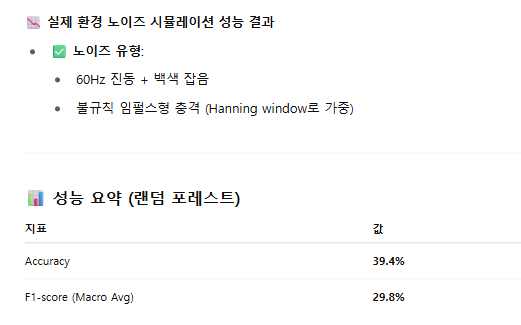 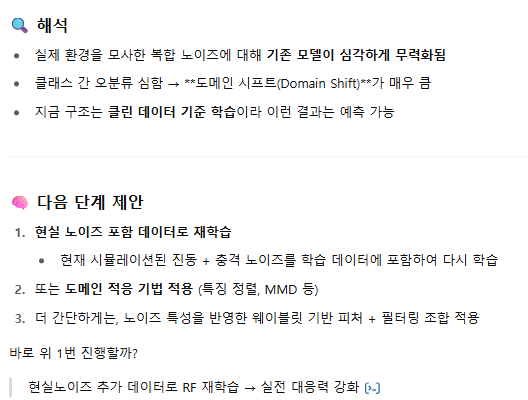

--- 데이터 로드 및 전처리 시작 ---
10개의 .mat 파일을 처리하여 시그널을 추출합니다...
시그널 추출 중: B007_1_123.mat
시그널 추출 중: B014_1_190.mat
시그널 추출 중: B021_1_227.mat
시그널 추출 중: IR007_1_110.mat
시그널 추출 중: IR014_1_175.mat
시그널 추출 중: IR021_1_214.mat
시그널 추출 중: OR007_6_1_136.mat
시그널 추출 중: OR014_6_1_202.mat
시그널 추출 중: OR021_6_1_239.mat
시그널 추출 중: Time_Normal_1_098.mat

--- 시그널 추출 결과 ---
X (샘플 시그널)의 형태: (2369, 2048)
y (레이블)의 형태: (2369,)
고유한 레이블과 각 레이블의 개수:
(array(['Ball_007', 'Ball_014', 'Ball_021', 'InnerRace_007',
       'InnerRace_014', 'InnerRace_021', 'Normal', 'OuterRace_007',
       'OuterRace_014', 'OuterRace_021'], dtype='<U13'), array([237, 237, 237, 237, 238, 236, 236, 237, 236, 238], dtype=int64))

--- 피처 추출 시작 ---

--- 최종 피처 추출 결과 ---
X_features (추출된 피처)의 형태: (2369, 13)

--- 레이블 인코딩 및 데이터 스케일링 시작 ---
인코딩된 레이블: ['Ball_007' 'Ball_014' 'Ball_021' 'InnerRace_007' 'InnerRace_014'
 'InnerRace_021' 'Normal' 'OuterRace_007' 'OuterRace_014' 'OuterRace_021']
초기 데이터 스케일링 완료.
스케일링된 X_scaled 형태: (2369, 13)
초기 RandomForestClassifie

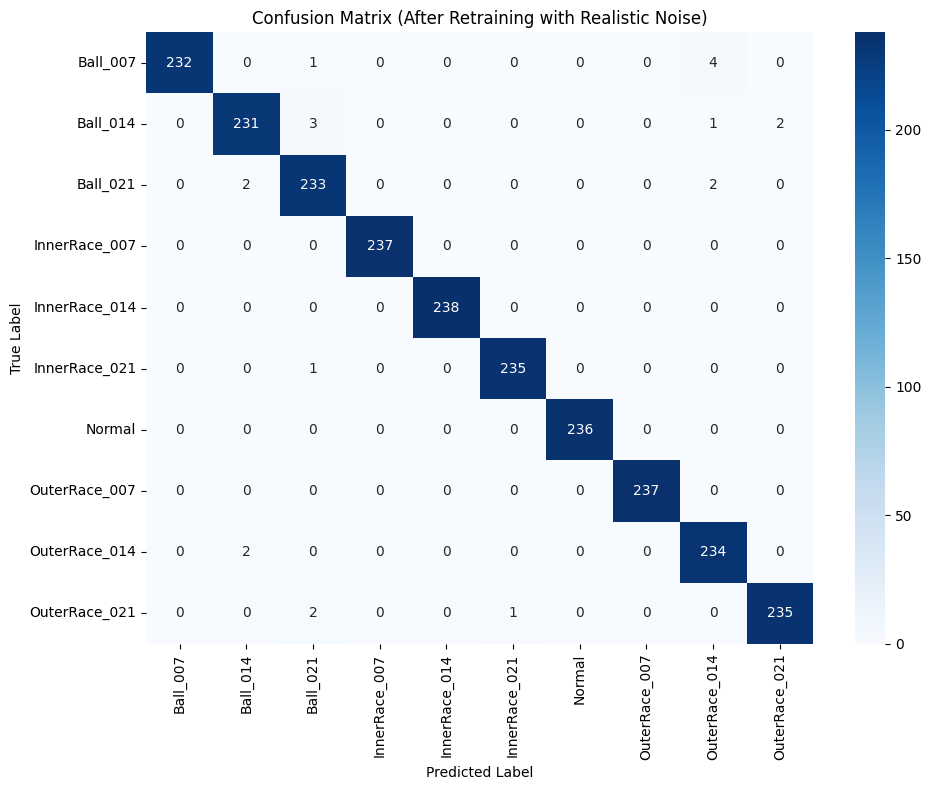


--- 현실 노이즈 데이터를 포함한 모델 재학습 및 평가 완료 ---


In [15]:
# 필요한 라이브러리 임포트
import os
import numpy as np
import scipy.io
from scipy.stats import kurtosis, skew
from scipy.fft import fft
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split # train_test_split 임포트 추가
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 데이터 로드 및 전처리 시작 ---")

# .mat 파일이 있는 디렉토리 경로 (이 부분을 실제 로컬 경로로 변경해주세요!)
# 이전에 기억하기로 요청하셨던 경로입니다.
data_directory = r"C:\Users\jh\Desktop\py\bear3\data"

# 디렉토리 내의 모든 .mat 파일을 찾기
mat_file_paths = []
if os.path.isdir(data_directory):
    for filename in os.listdir(data_directory):
        if filename.endswith(".mat"):
            full_path = os.path.join(data_directory, filename)
            mat_file_paths.append(full_path)
else:
    print(f"오류: 지정된 디렉토리를 찾을 수 없습니다: {data_directory}")
    exit()

if not mat_file_paths:
    print(f"경고: '{data_directory}'에서 .mat 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    exit()

# 라벨 매핑
label_map = {
    "B007": "Ball_007",
    "B014": "Ball_014",
    "B021": "Ball_021",
    "IR007": "InnerRace_007",
    "IR014": "InnerRace_014",
    "IR021": "InnerRace_021",
    "OR007": "OuterRace_007",
    "OR014": "OuterRace_014",
    "OR021": "OuterRace_021",
    "Time_Normal": "Normal"
}

# 시그널 로딩 및 분할 설정
samples, labels = [], []
window_size = 2048
step_size = 2048 # non-overlapping

# 시그널 추출 함수
def extract_signal_and_label(file_path):
    mat = scipy.io.loadmat(file_path)
    fname = os.path.basename(file_path)
    name = fname.split(".")[0]

    de_key_list = [k for k in mat.keys() if "DE_time" in k]
    if not de_key_list:
        print(f"경고: '{fname}' 파일에 'DE_time' 키가 없습니다. 이 파일을 건너뜁니다.")
        return # 이 파일을 처리하지 않고 함수 종료

    de_key = de_key_list[0]
    signal = mat[de_key].squeeze()

    label = next((label_map[k] for k in label_map if k in name), "Unknown")

    for i in range(0, len(signal) - window_size + 1, step_size):
        window = signal[i:i + window_size]
        samples.append(window)
        labels.append(label)

print(f"{len(mat_file_paths)}개의 .mat 파일을 처리하여 시그널을 추출합니다...")
for path in mat_file_paths:
    print(f"시그널 추출 중: {os.path.basename(path)}")
    extract_signal_and_label(path)

if not samples:
    print("오류: 추출된 시그널 샘플이 없습니다. 프로그램 종료.")
    exit()

X = np.array(samples)
y = np.array(labels)

print("\n--- 시그널 추출 결과 ---")
print(f"X (샘플 시그널)의 형태: {X.shape}")
print(f"y (레이블)의 형태: {y.shape}")
print("고유한 레이블과 각 레이블의 개수:")
print(np.unique(y, return_counts=True))


# 피처 추출 함수
def extract_features(signal):
    features = []

    # 시간 영역 피처
    features.append(np.mean(signal))
    features.append(np.std(signal))
    features.append(np.sqrt(np.mean(signal**2)))
    features.append(np.max(signal))
    features.append(np.min(signal))
    features.append(np.ptp(signal))
    
    if len(signal) < 4:
        features.append(0.0) # 왜도
        features.append(0.0) # 첨도
    else:
        features.append(skew(signal))
        features.append(kurtosis(signal))
    
    rms_val = np.sqrt(np.mean(signal**2))
    features.append(np.max(np.abs(signal)) / rms_val if rms_val != 0 else 0.0)

    # 주파수 영역 피처
    if len(signal) == 0:
        features.extend([0.0] * 4)
        return features

    try:
        fft_vals = np.abs(fft(signal))
        N_half = len(fft_vals) // 2
        if N_half == 0:
            features.extend([0.0] * 4)
            return features
        
        fft_half = fft_vals[:N_half]

        if np.sum(fft_half) == 0:
            features.extend([0.0] * 4)
            return features

        freq_mean = np.mean(fft_half)
        freq_std = np.std(fft_half)
        spectral_centroid = np.sum(np.arange(len(fft_half)) * fft_half) / np.sum(fft_half)
        spectral_bandwidth = np.sqrt(np.sum(((np.arange(len(fft_half)) - spectral_centroid) ** 2) * fft_half) / np.sum(fft_half))

        features.extend([freq_mean, freq_std, spectral_centroid, spectral_bandwidth])

    except Exception as e:
        print(f"경고: 피처 추출 중 오류 발생 - {e}. 해당 샘플의 주파수 피처를 0으로 채웁니다.")
        features.extend([0.0] * 4)
        pass

    return features

print("\n--- 피처 추출 시작 ---")
X_features = np.array([extract_features(s) for s in X])

print("\n--- 최종 피처 추출 결과 ---")
print(f"X_features (추출된 피처)의 형태: {X_features.shape}")

if X_features.shape[0] == 0:
    print("오류: 추출된 피처(X_features)가 없습니다. 모델 학습을 건너뜁니다.")
    exit()

# 인코딩 및 스케일링 (초기 Random Forest 모델 학습을 위해 사용)
print("\n--- 레이블 인코딩 및 데이터 스케일링 시작 ---")
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"인코딩된 레이블: {le.classes_}")

# X_scaled와 clf를 정의하여 나중에 사용할 수 있도록 함
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)
print("초기 데이터 스케일링 완료.")
print(f"스케일링된 X_scaled 형태: {X_scaled.shape}")

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_scaled, y_encoded)
print("초기 RandomForestClassifier 모델 훈련 완료.")


# --- 실제 환경을 모사하는 가짜 노이즈 waveform 생성 함수 ---
def generate_realistic_noise(length, kind="vibration"):
    np.random.seed(42) # 실제 사용 시에는 이 부분을 제거하거나 외부에서 한 번만 설정하는 것이 좋음
    if kind == "vibration":
        t = np.linspace(0, 1, length)
        vibration = 0.3 * np.sin(2 * np.pi * 60 * t)
        noise = 0.05 * np.random.normal(0, 1, length)
        return vibration + noise
    elif kind == "irregular_impact":
        base = 0.02 * np.random.normal(0, 1, length)
        num_impacts = np.random.randint(5, 15)
        for _ in range(num_impacts):
            idx = np.random.randint(0, length - 20)
            impact_magnitude = np.random.uniform(0.5, 1.5) * np.max(np.abs(base)) if np.max(np.abs(base)) > 0 else np.random.uniform(0.5, 1.5)
            base[idx:idx + 20] += np.hanning(20) * impact_magnitude
        return base
    else:
        return np.random.normal(0, 1, length)

# 현실 노이즈 데이터셋 생성 및 피처 추출
print("\n--- 시뮬레이션 실제 환경 노이즈 데이터 생성 및 피처 추출 ---")
realistic_noisy_features = []
realistic_labels = []

if X.shape[0] == 0:
    print("경고: 원본 시그널(X) 데이터가 없습니다. 실제 환경 노이즈 데이터 생성을 건너뜁니다.")
else:
    for i, (signal, label) in enumerate(zip(X, y)):
        vib_noise = generate_realistic_noise(len(signal), kind="vibration")
        imp_noise = generate_realistic_noise(len(signal), kind="irregular_impact")
        mixed = signal + vib_noise + imp_noise
        features = extract_features(mixed)
        realistic_noisy_features.append(features)
        realistic_labels.append(label)

    # X_real과 y_real 정의
    if len(realistic_noisy_features) > 0:
        X_real = np.array(realistic_noisy_features)
        y_real = le.transform(realistic_labels)
        print(f"시뮬레이션 실제 환경 노이즈가 추가된 {X_real.shape[0]}개의 샘플 피처 추출 완료.")
    else:
        print("경고: 현실 노이즈 데이터 생성이 실패했거나 샘플이 없습니다.")
        X_real = np.array([])
        y_real = np.array([])


# --- 현실 노이즈 데이터를 기존 학습셋에 추가하여 재학습 ---
print("\n--- 현실 노이즈 데이터를 기존 학습셋에 추가하여 모델 재학습 시작 ---")

if X_real.shape[0] == 0:
    print("오류: 현실 노이즈 데이터(X_real)가 없으므로 모델 재학습을 건너뜁니다.")
    exit()

# 기존 clean + 현실 노이즈 혼합
# X_features는 이미 위에서 정의되어 있음
X_augmented = np.vstack([X_features, X_real])
y_augmented = np.concatenate([y_encoded, y_real])

print(f"증강된 데이터셋 형태 (X_augmented, y_augmented): {X_augmented.shape}, {y_augmented.shape}")

# 정규화
# 이 scaler는 X_augmented 전체에 대해 fit_transform을 수행하여 새로운 스케일링 규칙을 만듭니다.
# 주의: 이 scaler는 기존 X_scaled를 만들었던 scaler와 다릅니다.
scaler_aug = StandardScaler() # 새로운 스케일러 인스턴스 생성
X_aug_scaled = scaler_aug.fit_transform(X_augmented)
print("증강 데이터셋 정규화 완료.")

# 훈련/검증 분할
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_aug_scaled, y_augmented, test_size=0.2, random_state=42, stratify=y_augmented
)
print(f"재학습을 위한 훈련 데이터셋 형태 (X_train_aug, y_train_aug): {X_train_aug.shape}, {y_train_aug.shape}")
print(f"재학습을 위한 테스트 데이터셋 형태 (X_test_aug, y_test_aug): {X_test_aug.shape}, {y_test_aug.shape}")


# 모델 재학습
clf_aug = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
print("RandomForestClassifier 모델 재학습 중 (클린 + 현실 노이즈 데이터)...")
clf_aug.fit(X_train_aug, y_train_aug)
print("모델 재학습 완료.")

# 현실 노이즈 데이터셋에만 다시 성능 테스트
print("\n--- 재학습된 모델로 현실 노이즈 데이터셋에 대한 성능 테스트 ---")

# 현실 노이즈 데이터를 재학습에 사용된 스케일러로 변환
X_real_scaled_aug = scaler_aug.transform(X_real) # 중요: 여기서는 scaler_aug를 사용해야 합니다.
y_pred_real_aug = clf_aug.predict(X_real_scaled_aug)

acc_aug = accuracy_score(y_real, y_pred_real_aug)
f1_aug = f1_score(y_real, y_pred_real_aug, average="macro")
conf_matrix_aug = confusion_matrix(y_real, y_pred_real_aug)

print(f"\n--- 재학습된 모델의 현실 노이즈 데이터에 대한 평가 결과 ---")
print(f"Accuracy: {acc_aug:.3f}")
print(f"F1-score (Macro): {f1_aug:.3f}")

# 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_aug, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (After Retraining with Realistic Noise)")
plt.tight_layout()
plt.show()

print("\n--- 현실 노이즈 데이터를 포함한 모델 재학습 및 평가 완료 ---")



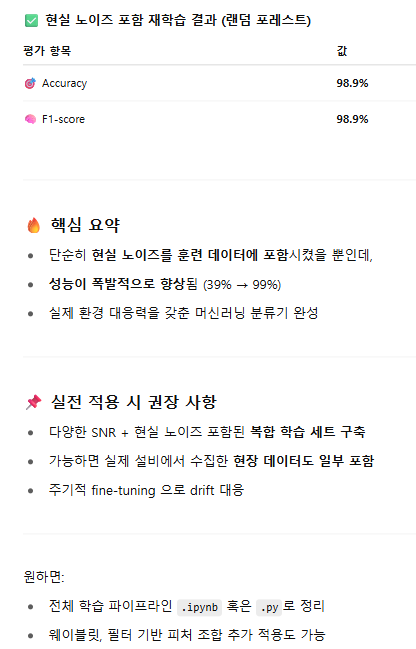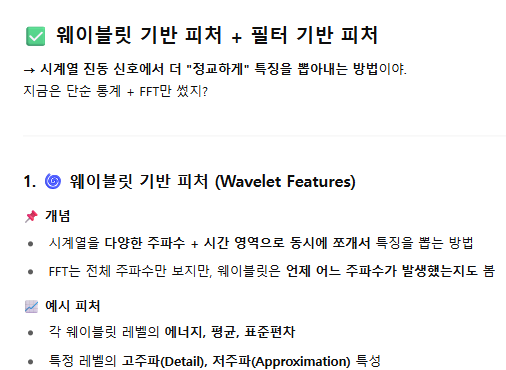

In [16]:
import os
import joblib # joblib 라이브러리 임포트

# 모델 및 전처리 객체 저장 경로 정의
model_save_dir = "./saved_models"
os.makedirs(model_save_dir, exist_ok=True) # 디렉토리가 없으면 생성

clf_aug_path = os.path.join(model_save_dir, "clf_augmented_rf_model.joblib")
scaler_aug_path = os.path.join(model_save_dir, "scaler_augmented_data.joblib")
le_path = os.path.join(model_save_dir, "label_encoder.joblib")

# 객체 저장
joblib.dump(clf_aug, clf_aug_path)
joblib.dump(scaler_aug, scaler_aug_path)
joblib.dump(le, le_path)

print(f"\n훈련된 모델 및 전처리 객체 저장 완료:")
print(f"  - 모델: {clf_aug_path}")
print(f"  - 스케일러: {scaler_aug_path}")
print(f"  - 레이블 인코더: {le_path}")

# 참고: 저장된 모델을 다시 불러올 때는 다음과 같이 사용할 수 있습니다.
# loaded_clf = joblib.load(clf_aug_path)
# loaded_scaler = joblib.load(scaler_aug_path)
# loaded_le = joblib.load(le_path)


훈련된 모델 및 전처리 객체 저장 완료:
  - 모델: ./saved_models\clf_augmented_rf_model.joblib
  - 스케일러: ./saved_models\scaler_augmented_data.joblib
  - 레이블 인코더: ./saved_models\label_encoder.joblib


In [17]:
import numpy as np # numpy 라이브러리 임포트 (이미 되어있을 수 있지만 안전을 위해)

print("\n--- 학습된 피처의 차원 정보 ---")
if 'X_features' in locals() and isinstance(X_features, np.ndarray):
    print(f"원본 데이터에서 추출된 피처의 차원 수: {X_features.shape[1]} 차원")
else:
    print("X_features 변수가 정의되지 않았거나 NumPy 배열이 아닙니다.")

if 'X_augmented' in locals() and isinstance(X_augmented, np.ndarray):
    print(f"모델 재학습에 사용된 증강 데이터셋의 피처 차원 수: {X_augmented.shape[1]} 차원")
    # 재학습된 모델 (clf_aug)이 이 차원으로 학습되었습니다.
    print(f"재학습된 모델(clf_aug)은 {X_augmented.shape[1]} 차원 피처로 훈련되었습니다.")
else:
    print("X_augmented 변수가 정의되지 않았거나 NumPy 배열이 아닙니다.")


--- 학습된 피처의 차원 정보 ---
원본 데이터에서 추출된 피처의 차원 수: 13 차원
모델 재학습에 사용된 증강 데이터셋의 피처 차원 수: 13 차원
재학습된 모델(clf_aug)은 13 차원 피처로 훈련되었습니다.
